In [1]:
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from scipy import sparse

project_dir = Path("/mnt/yiming/nfs_share/projects/hypoblast")
os.chdir(project_dir)
sys.path.append(str(project_dir))

print(Path.cwd())

fig_dir = Path("results/figures/312_larry_clonality")
fig_dir.mkdir(parents=True, exist_ok=True)

table_dir = Path("results/tables/312_larry_clonality")
table_dir.mkdir(parents=True, exist_ok=True)

processed_dir = Path("results/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

/mnt/yiming/nfs_share/projects/hypoblast


In [2]:
import numpy as np
import pandas as pd
from scipy import stats as scipy_stats
from itertools import combinations


# ------------------------------------------------------------------
# Basic metrics
# ------------------------------------------------------------------

def compute_clone_table(adata, clone_col, celltype_col):
    return pd.crosstab(
        adata.obs[clone_col],
        adata.obs[celltype_col]
    )


def compute_basic_stats(clone_table):
    cells_per_clone = clone_table.sum(axis=1)

    stats = {
        "total_clones": len(clone_table),
        "total_cells": clone_table.sum().sum(),
        "mean_clone_size": cells_per_clone.mean(),
        "median_clone_size": cells_per_clone.median(),
        "max_clone_size": cells_per_clone.max(),
        "single_cell_clones": (cells_per_clone == 1).sum(),
        "expanded_clones": (cells_per_clone >= 2).sum(),
    }

    stats["cells_per_clone"] = cells_per_clone

    return stats


# ------------------------------------------------------------------
# Diversity metrics
# ------------------------------------------------------------------

def gini_coefficient(x):
    x = np.sort(x)
    n = len(x)
    cumx = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n


def shannon_entropy(series):
    proportions = series / series.sum()
    return -np.sum(proportions * np.log2(proportions + 1e-10))


def simpson_diversity(series):
    proportions = series / series.sum()
    return 1 - np.sum(proportions ** 2)


def compute_diversity_metrics(cells_per_clone):
    gini = gini_coefficient(cells_per_clone.values)
    shannon = shannon_entropy(cells_per_clone)
    max_entropy = np.log2(len(cells_per_clone))
    normalized_entropy = shannon / max_entropy
    simpson = simpson_diversity(cells_per_clone)
    expansion_index = cells_per_clone[cells_per_clone >= 2].sum() / cells_per_clone.sum()

    return {
        "gini": gini,
        "shannon": shannon,
        "normalized_entropy": normalized_entropy,
        "simpson": simpson,
        "expansion_index": expansion_index
    }


def compute_jaccard_matrix(adata, clone_col, celltype_col):
    cell_types = sorted(adata.obs[celltype_col].unique())
    n = len(cell_types)
    matrix = np.zeros((n, n))

    for i in range(n):
        clones_i = set(
            adata[adata.obs[celltype_col] == cell_types[i]].obs[clone_col]
        )
        for j in range(n):
            if i == j:
                matrix[i, j] = 1.0
            elif i < j:
                clones_j = set(
                    adata[adata.obs[celltype_col] == cell_types[j]].obs[clone_col]
                )
                intersection = len(clones_i & clones_j)
                union = len(clones_i | clones_j)
                similarity = intersection / union if union > 0 else 0
                matrix[i, j] = similarity
                matrix[j, i] = similarity

    return cell_types, matrix


def run_clonality_analysis(
    adata,
    clone_col="larry_clone",
    celltype_col="celltype_work"
):
    clone_table = compute_clone_table(adata, clone_col, celltype_col)

    basic = compute_basic_stats(clone_table)
    diversity = compute_diversity_metrics(basic["cells_per_clone"])

    cell_types, jaccard_matrix = compute_jaccard_matrix(
        adata,
        clone_col,
        celltype_col
    )

    results = {
        "basic_stats": basic,
        "diversity": diversity,
        "jaccard_matrix": jaccard_matrix,
        "cell_types": cell_types
    }

    return results



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from scipy import stats as scipy_stats

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16
})



def _compute_clonality_core(adata):
    """
    Compute all clonality statistics needed for Fig.
    """

    # Clone x CellType table
    full_clone_celltype = pd.crosstab(
        adata.obs['larry_clone'],
        adata.obs['CellType_short']
    )

    cells_per_clone = full_clone_celltype.sum(axis=1)
    clone_sizes = cells_per_clone.value_counts().sort_index()

    total_clones = len(full_clone_celltype)
    total_cells = full_clone_celltype.sum().sum()

    clones_with_1_cell = sum(cells_per_clone == 1)
    clones_with_2plus_cells = sum(cells_per_clone >= 2)

    # ---- Gini ----
    def gini_coefficient(x):
        x = np.sort(x)
        n = len(x)
        cumx = np.cumsum(x)
        return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n

    gini = gini_coefficient(cells_per_clone.values)

    # ---- Shannon ----
    def shannon_entropy(series):
        proportions = series / series.sum()
        return -np.sum(proportions * np.log2(proportions + 1e-10))

    shannon = shannon_entropy(cells_per_clone)
    max_entropy = np.log2(len(cells_per_clone))
    normalized_entropy = shannon / max_entropy

    # ---- Simpson ----
    def simpson_diversity(series):
        proportions = series / series.sum()
        return 1 - np.sum(proportions ** 2)

    simpson = simpson_diversity(cells_per_clone)

    expansion_index = cells_per_clone[cells_per_clone >= 2].sum() / total_cells

    # ---- Cell type statistics ----
    celltype_clone_counts = {}
    for cell_type in adata.obs['CellType_short'].unique():
        type_cells = adata[adata.obs['CellType_short'] == cell_type]
        type_clones = type_cells.obs['larry_clone'].nunique()

        celltype_clone_counts[cell_type] = {
            'n_cells': len(type_cells),
            'n_clones': type_clones,
            'cells_per_clone': len(type_cells) / type_clones if type_clones > 0 else 0
        }

    # ---- Jaccard ----
    def calculate_jaccard(celltype1, celltype2):
        clones1 = set(adata[adata.obs['CellType_short'] == celltype1].obs['larry_clone'])
        clones2 = set(adata[adata.obs['CellType_short'] == celltype2].obs['larry_clone'])
        intersection = len(clones1.intersection(clones2))
        union = len(clones1.union(clones2))
        return intersection / union if union > 0 else 0

    cell_types = sorted(adata.obs['CellType_short'].unique())
    n_types = len(cell_types)
    jaccard_matrix = np.zeros((n_types, n_types))

    for i in range(n_types):
        for j in range(n_types):
            if i == j:
                jaccard_matrix[i, j] = 1.0
            elif i < j:
                similarity = calculate_jaccard(cell_types[i], cell_types[j])
                jaccard_matrix[i, j] = similarity
                jaccard_matrix[j, i] = similarity

    return {
        "cells_per_clone": cells_per_clone,
        "clone_sizes": clone_sizes,
        "gini": gini,
        "shannon": shannon,
        "normalized_entropy": normalized_entropy,
        "simpson": simpson,
        "expansion_index": expansion_index,
        "celltype_clone_counts": celltype_clone_counts,
        "jaccard_matrix": jaccard_matrix,
        "cell_types": cell_types,
        "n_types": n_types
    }


# ------------------------------------------------------------------
# FIG1
# ------------------------------------------------------------------

def plot_fig1(adata, save_path=None):
    data = _compute_clonality_core(adata)

    plt.figure(figsize=(6, 5))
    plt.bar(data["clone_sizes"].index,
            data["clone_sizes"].values,
            alpha=0.7,
            color='skyblue')

    plt.xlabel('Cells per clone')
    plt.ylabel('Number of clones')
    plt.title('Clone Size Distribution (Linear)')
    plt.grid(False)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')

    plt.close()


# ------------------------------------------------------------------
# FIG2
# ------------------------------------------------------------------

def plot_fig2(adata, save_path=None):
    data = _compute_clonality_core(adata)

    plt.figure(figsize=(6, 5))

    sorted_sizes = np.sort(data["cells_per_clone"].values)
    yvals = np.arange(1, len(sorted_sizes)+1) / len(sorted_sizes)

    plt.plot(sorted_sizes, yvals, 'b-', linewidth=2)

    plt.xlabel('Clone size (cells)')
    plt.ylabel('Cumulative fraction')
    plt.title('Cumulative Clone Size Distribution')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')

    plt.close()


# ------------------------------------------------------------------
# FIG3
# ------------------------------------------------------------------

def plot_fig3(adata, save_path=None):
    data = _compute_clonality_core(adata)

    plt.figure(figsize=(6, 5))

    plt.loglog(data["clone_sizes"].index,
               data["clone_sizes"].values,
               'bo', alpha=0.6)

    plt.xlabel('Clone size (log scale)')
    plt.ylabel('Number of clones (log scale)')
    plt.title('Clone Size Distribution (Log-Log)')
    plt.grid(True, alpha=0.3, which='both')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')

    plt.close()


# ------------------------------------------------------------------
# FIG4
# ------------------------------------------------------------------

def plot_fig4(adata, save_path=None):
    data = _compute_clonality_core(adata)

    plt.figure(figsize=(6, 5))

    cumulative_clone_sizes = np.cumsum(np.sort(data["cells_per_clone"].values))
    cumulative_clone_fraction = cumulative_clone_sizes / cumulative_clone_sizes[-1]
    perfect_line = np.linspace(0, 1, len(cumulative_clone_fraction))

    plt.plot(perfect_line, perfect_line, 'k--', label='Perfect equality')
    plt.plot(perfect_line, cumulative_clone_fraction, 'r-', linewidth=2, label='Actual distribution')
    plt.fill_between(perfect_line, perfect_line, cumulative_clone_fraction, alpha=0.3)

    plt.xlabel('Cumulative fraction of clones')
    plt.ylabel('Cumulative fraction of cells')
    plt.title(f'Lorenz Curve (Gini = {data["gini"]:.3f})')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')

    plt.close()


# ------------------------------------------------------------------
# FIG5
# ------------------------------------------------------------------

def plot_fig5(adata, save_path=None):
    data = _compute_clonality_core(adata)

    plt.figure(figsize=(8, 6))

    celltypes = list(data["celltype_clone_counts"].keys())
    clone_counts = [stats['n_clones'] for stats in data["celltype_clone_counts"].values()]
    cell_counts = [stats['n_cells'] for stats in data["celltype_clone_counts"].values()]

    x = np.arange(len(celltypes))
    width = 0.35

    plt.bar(x - width/2, cell_counts, width,
            label='Cells', color='lightblue')
    plt.bar(x + width/2, clone_counts, width,
            label='Clones', color='lightcoral')

    plt.xlabel('Cell Type')
    plt.ylabel('Count')
    plt.title('Cells vs Clones per Cell Type')
    plt.xticks(x, celltypes, rotation=45, ha='right')
    plt.legend()
    plt.grid(False)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')

    plt.close()


# ------------------------------------------------------------------
# FIG6
# ------------------------------------------------------------------

def plot_fig6(adata, save_path=None):
    data = _compute_clonality_core(adata)

    plt.figure(figsize=(8, 6))

    im = plt.imshow(data["jaccard_matrix"],
                    cmap='Reds',
                    vmin=0,
                    vmax=1)

    plt.xticks(range(data["n_types"]),
               [ct[:8] for ct in data["cell_types"]],
               rotation=45, ha='right')
    plt.yticks(range(data["n_types"]),
               data["cell_types"])

    plt.title('Clone Sharing Between Cell Types')
    plt.colorbar(im, label='Jaccard Similarity')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='svg', dpi=300, bbox_inches='tight')

    plt.close()


# ------------------------------------------------------------------
# plotting
# ------------------------------------------------------------------

def generate_all_figures(adata, output_dir):
    import os
    os.makedirs(output_dir, exist_ok=True)

    plot_fig1(adata, f"{output_dir}/fig1_clone_size_linear.svg")
    plot_fig2(adata, f"{output_dir}/fig2_cumulative_distribution.svg")
    plot_fig3(adata, f"{output_dir}/fig3_loglog_distribution.svg")
    plot_fig4(adata, f"{output_dir}/fig4_lorenz_curve.svg")
    plot_fig5(adata, f"{output_dir}/fig5_celltype_clone_relationship.svg")
    plot_fig6(adata, f"{output_dir}/fig6_clone_sharing_heatmap.svg")

    
# ------------------------------------------------------------------
# report  
# ------------------------------------------------------------------

def generate_full_clone_report(
    adata,
    output_dir,
    dataset_name=None,
    return_data=True
):
    """
    Generate full clonality report (Fig1–Fig6).

    Parameters
    ----------
    adata : AnnData
    output_dir : str
        Directory to save figures.
    dataset_name : str or None
        Optional prefix for figure titles and filenames.
    return_data : bool
        Whether to return computed clonality statistics.

    Returns
    -------
    dict (optional)
        Core clonality statistics.
    """

    import os
    os.makedirs(output_dir, exist_ok=True)

    # ---- compute once ----
    data = _compute_clonality_core(adata)

    # ---- filename prefix ----
    prefix = f"{dataset_name}_" if dataset_name else ""

    # ---- FIGURES ----
    plot_fig1(adata, f"{output_dir}/{prefix}fig1_clone_size_linear.svg")
    plot_fig2(adata, f"{output_dir}/{prefix}fig2_cumulative_distribution.svg")
    plot_fig3(adata, f"{output_dir}/{prefix}fig3_loglog_distribution.svg")
    plot_fig4(adata, f"{output_dir}/{prefix}fig4_lorenz_curve.svg")
    plot_fig5(adata, f"{output_dir}/{prefix}fig5_celltype_clone_relationship.svg")
    plot_fig6(adata, f"{output_dir}/{prefix}fig6_clone_sharing_heatmap.svg")

    # ---- console summary (paper-style metrics) ----
    print("==================================================")
    if dataset_name:
        print(f"Clonality Report: {dataset_name}")
    else:
        print("Clonality Report")

    print("--------------------------------------------------")
    print(f"Total clones: {len(data['cells_per_clone'])}")
    print(f"Gini coefficient: {data['gini']:.4f}")
    print(f"Shannon entropy: {data['shannon']:.4f}")
    print(f"Normalized entropy: {data['normalized_entropy']:.4f}")
    print(f"Simpson diversity: {data['simpson']:.4f}")
    print(f"Expansion index: {data['expansion_index']:.4f}")
    print("==================================================")

    if return_data:
        return data



In [3]:
candidate_paths = [
    Path("/mnt/yiming/nfs_share/projects/hypoblast/results/processed/larry_d4_revised_labels_subcluster.h5ad"),
]

larry_d4_path = next((p for p in candidate_paths if p.exists()), None)
if larry_d4_path is None:
    raise FileNotFoundError(
        "Could not find the Day 4 LARRY h5ad file. Checked:\n" +
        "\n".join(str(p) for p in candidate_paths)
    )

larry_d4 = sc.read_h5ad(larry_d4_path)
print(f"Loaded: {larry_d4_path}")
print(larry_d4)

celltype_key = 'CellType_short'

Loaded: /mnt/yiming/nfs_share/projects/hypoblast/results/processed/larry_d4_revised_labels_subcluster.h5ad
AnnData object with n_obs × n_vars = 4618 × 30428
    obs: 'scrublet_result', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'CellType_man', 'larry_barcode', 'larry_clone', 'CellType_revised_id', 'CellType_revised_full', 'CellType_revised_short', 'CellType_with_endo_sub', 'Endo_subcluster_man', 'CellType_short', 'CellType_short_sub'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'CellType_revised_short_colors', 'CellType_short_colors', 

In [4]:
clone_key = "larry_clone"
required_obs = [celltype_key, clone_key]
missing_obs = [x for x in required_obs if x not in larry_d4.obs.columns]
if missing_obs:
    raise KeyError(f"Missing required obs columns: {missing_obs}")

qc_summary = pd.Series({
    "n_cells": larry_d4.n_obs,
    "n_genes": larry_d4.n_vars,
    "n_annotated_cells": larry_d4.obs[celltype_key].notna().sum(),
    "n_clone_assigned_cells": larry_d4.obs[clone_key].notna().sum(),
    "n_unique_clones": larry_d4.obs[clone_key].dropna().astype(str).nunique(),
}, name="value").to_frame()
qc_summary.to_csv(table_dir / "larry_d4_basic_qc.csv")
qc_summary

,value
n_cells,4618
n_genes,30428
n_annotated_cells,4618
n_clone_assigned_cells,4618
n_unique_clones,2626


In [5]:
clone_sizes = (
    larry_d4.obs.loc[larry_d4.obs[clone_key].notna(), clone_key]
    .astype(str)
    .value_counts()
    .rename_axis("clone_id")
    .rename("n_cells")
    .to_frame()
)
clone_sizes.to_csv(table_dir / "larry_d4_clone_sizes.csv")
clone_sizes.describe()

,n_cells
count,2626.000000
mean,1.758568
std,1.548570
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,15.000000


In [6]:
clonality_report_dir = fig_dir / 'd4_full_clonality_report'

clonality_results = generate_full_clone_report(
    larry_d4,
    output_dir=str(clonality_report_dir),
    dataset_name='larry_d4',
    return_data=True,
)

# Save the clone-sharing Jaccard matrix as a table.
larry_d4_jaccard_df = pd.DataFrame(
    clonality_results['jaccard_matrix'],
    index=clonality_results['cell_types'],
    columns=clonality_results['cell_types'],
)
larry_d4_jaccard_df.to_csv(table_dir / 'larry_d4_celltype_clone_jaccard_matrix.csv')
larry_d4_jaccard_df

Clonality Report: larry_d4
--------------------------------------------------
Total clones: 2626
Gini coefficient: 0.3397
Shannon entropy: 10.9932
Normalized entropy: 0.9678
Simpson diversity: 0.9993
Expansion index: 0.6312


,Adv Mes,Amn,Endoderm,Epi,HE,Nasc Mes,PGC,Trans ExM
Adv Mes,1.000000,0.031377,0.048220,0.050379,0.154713,0.042312,0.071050,0.095713
Amn,0.031377,1.000000,0.000000,0.034848,0.027829,0.030660,0.016279,0.009597
Endoderm,0.048220,0.000000,1.000000,0.005587,0.064133,0.015337,0.034375,0.079692
Epi,0.050379,0.034848,0.005587,1.000000,0.017956,0.035088,0.020301,0.019746
HE,0.154713,0.027829,0.064133,0.017956,1.000000,0.026365,0.054159,0.080068
Nasc Mes,0.042312,0.030660,0.015337,0.035088,0.026365,1.000000,0.031325,0.038153
PGC,0.071050,0.016279,0.034375,0.020301,0.054159,0.031325,1.000000,0.036072
Trans ExM,0.095713,0.009597,0.079692,0.019746,0.080068,0.038153,0.036072,1.000000


In [7]:
# ------------------------------------------------------------------
# Source clone check  
# ------------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def quick_clone_check(adata, column_to_check, cell_type_A, cell_type_B):
    """Quick one-line results"""
    clones_A = set(adata.obs[adata.obs[column_to_check] == cell_type_A]['larry_clone'].dropna())
    clones_B = set(adata.obs[adata.obs[column_to_check] == cell_type_B]['larry_clone'].dropna())
    shared = clones_A.intersection(clones_B)
    
    print(f"A clones: {len(clones_A)} | B clones: {len(clones_B)} | Shared: {len(shared)} | Prop A goes to B: {len(shared)/len(clones_A) if clones_A else 0:.1%}")
    return len(clones_A), len(clones_B), len(shared)


def analyze_multiple_to_B(adata, column_to_check, source_cell_types, target_B):

    # Get clones for target B
    clones_B = set(adata.obs[adata.obs[column_to_check] == target_B]['larry_clone'].dropna())
    n_clones_B = len(clones_B)
    
    print(f"ANALYSIS: How many clones of different sources go to {target_B}?")
    print("=" * 70)
    print(f"Target cell type: {target_B} ({n_clones_B} clones)")
    print("Metric: (shared clones between source and B) / (source clones)")
    print("=" * 70)
    
    results = []
    
    for source_A in source_cell_types:
        # Get clones for source A
        clones_A = set(adata.obs[adata.obs[column_to_check] == source_A]['larry_clone'].dropna())
        n_clones_A = len(clones_A)
        
        # Find shared clones
        shared_clones = clones_A.intersection(clones_B)
        n_shared = len(shared_clones)
        
        # Calculate percentage: shared/source_A
        percentage = (n_shared / n_clones_A * 100) if n_clones_A > 0 else 0
        
        # Get clones that actually contain both types
        clones_with_both = []
        for clone in shared_clones:
            clone_cell_types = adata.obs[adata.obs['larry_clone'] == clone][column_to_check]
            if (source_A in clone_cell_types.values) and (target_B in clone_cell_types.values):
                clones_with_both.append(clone)
        
        results.append({
            'Source': source_A,
            'Target': target_B,
            'Source Clones': n_clones_A,
            'Target Clones': n_clones_B,
            'Shared Clones': n_shared,
            'Clones with Both': len(clones_with_both),
            'Percentage (shared/source)': percentage,
            'Ratio (shared/source)': f"{n_shared}/{n_clones_A}",
            'Shared Clone IDs': list(shared_clones),
            'Clones with Both IDs': clones_with_both
        })
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    
    # Sort by Percentage (decreasing order) - MAIN SORTING
    results_df = results_df.sort_values('Percentage (shared/source)', ascending=False)
    
    # Print results table
    print("\nRESULTS (sorted by percentage, highest first):")
    print("=" * 80)
    
    display_df = results_df[['Source', 'Source Clones', 'Shared Clones', 
                           'Percentage (shared/source)', 'Ratio (shared/source)']].copy()
    display_df['Percentage (shared/source)'] = display_df['Percentage (shared/source)'].round(2)
    
    print(display_df.to_string(index=False))

    # Required execution fix: visualize_sources_to_B expects this DataFrame.
    return results_df


def visualize_sources_to_B(
    adata,
    column_to_check,
    source_cell_types,
    target_B,
    fig_title,
    figsize=(10, 6),
    save_path=None,
    dpi=300,
):
    
    # Get analysis results
    results_df = analyze_multiple_to_B(
        adata,
        column_to_check,
        source_cell_types,
        target_B,
    )
    
    # Create figure with just one plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Get data for plotting
    sources = results_df["Source"]
    percentages = results_df["Percentage (shared/source)"]
    
    # Create horizontal bar chart
    y_pos = np.arange(len(sources))
    bars = ax.barh(
        y_pos,
        percentages,
        color="lightblue",
        edgecolor="navy",
        alpha=0.8,
    )
    
    # Customize y-axis
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sources)
    ax.invert_yaxis()
    
    # Customize x-axis
    ax.set_xlabel(f"% of source clones that contain {target_B}", fontsize=12)
    ax.set_xlim([0, max(percentages) * 1.15])
    
    # Add title
    ax.set_title(
        fig_title,
        fontsize=14,
        pad=20,
    )
    
    # Add percentage labels on bars
    for bar, percentage, source_clones, shared_clones in zip(
        bars,
        percentages,
        results_df["Source Clones"],
        results_df["Shared Clones"],
    ):
        width = bar.get_width()
        
        if width > 5:
            label_x = width - 1
            ha = "right"
            color = "black"
            fontweight = "bold"
        else:
            label_x = width + 0.5
            ha = "left"
            color = "black"
            fontweight = "normal"
        
        ax.text(
            label_x,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.1f}%",
            ha=ha,
            va="center",
            color=color,
            fontweight=fontweight,
            fontsize=10,
        )
    
    # Add grid
    ax.grid(True, axis="x", alpha=0.3, linestyle="--")
    
    # Add reference lines
    max_perc = max(percentages)
    for perc in [25, 50, 75]:
        if perc <= max_perc:
            ax.axvline(
                x=perc,
                color="red",
                linestyle=":",
                alpha=0.3,
                linewidth=1,
            )
    
    plt.tight_layout()
    
    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=dpi,
            bbox_inches="tight",
        )
        print(f"Figure saved to {save_path}")
    
    plt.show()
    
    return results_df

In [8]:
# ------------------------------------------------------------------
# Plot shared clones AB only: split version
# ------------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def assign_AB_clone_type(
    adata,
    celltype_label,
    celltype_A,
    celltype_B,
    clone_key="larry_clone",
    clone_type_key="clone_type_AB",
):
    """
    Assign clone type for cells in A/B populations:
    - Shared: A or B cells from clones containing both A and B
    - A-only: A cells from clones containing only A among A/B
    - B-only: B cells from clones containing only B among A/B
    - Other: all other cells
    """

    print("Recovering AB clone type from larry_clone...")

    adata.obs[clone_type_key] = "Other"

    clone_ids = adata.obs[clone_key].dropna().unique()

    mixed_clone_ids = []

    for clone_id in clone_ids:
        clone_mask = adata.obs[clone_key] == clone_id
        celltypes_in_clone = set(adata.obs.loc[clone_mask, celltype_label].dropna())

        has_A = celltype_A in celltypes_in_clone
        has_B = celltype_B in celltypes_in_clone

        if has_A and has_B:
            mixed_clone_ids.append(clone_id)

            type_A_mask = clone_mask & (adata.obs[celltype_label] == celltype_A)
            type_B_mask = clone_mask & (adata.obs[celltype_label] == celltype_B)

            adata.obs.loc[type_A_mask, clone_type_key] = "Shared"
            adata.obs.loc[type_B_mask, clone_type_key] = "Shared"

        elif has_A and not has_B:
            type_A_mask = clone_mask & (adata.obs[celltype_label] == celltype_A)
            adata.obs.loc[type_A_mask, clone_type_key] = f"{celltype_A}-only"

        elif has_B and not has_A:
            type_B_mask = clone_mask & (adata.obs[celltype_label] == celltype_B)
            adata.obs.loc[type_B_mask, clone_type_key] = f"{celltype_B}-only"

    print(f"Mixed clones containing both {celltype_A} and {celltype_B}: {len(mixed_clone_ids)}")
    print(f"{celltype_A}-only cells: {(adata.obs[clone_type_key] == f'{celltype_A}-only').sum()}")
    print(f"{celltype_B}-only cells: {(adata.obs[clone_type_key] == f'{celltype_B}-only').sum()}")
    print(f"Shared cells: {(adata.obs[clone_type_key] == 'Shared').sum()}")

    return mixed_clone_ids

def plot_AB_population(
    adata,
    celltype_label,
    celltype_A,
    celltype_B,
    colorA,
    colorB,
    figsize=(5, 5),
    point_size_bg=3,
    point_size_celltype=15,
    alpha_bg=0.1,
    alpha_celltype=0.7,
    title=None,
    legend=True,
    legend_loc="upper right",
    legend_bbox_to_anchor=None,
    save_path=None,
):
    """
    Plot UMAP with all cells in grey background and A/B populations highlighted.
    """

    fig, ax = plt.subplots(figsize=figsize)

    all_umap_x = adata.obsm["X_umap"][:, 0]
    all_umap_y = adata.obsm["X_umap"][:, 1]

    mask_A = adata.obs[celltype_label] == celltype_A
    mask_B = adata.obs[celltype_label] == celltype_B

    ax.scatter(
        all_umap_x,
        all_umap_y,
        s=point_size_bg,
        alpha=alpha_bg,
        color="grey",
        label="All cells",
    )

    ax.scatter(
        adata.obsm["X_umap"][mask_A.values, 0],
        adata.obsm["X_umap"][mask_A.values, 1],
        s=point_size_celltype,
        alpha=alpha_celltype,
        color=colorA,
        label=celltype_A,
    )

    ax.scatter(
        adata.obsm["X_umap"][mask_B.values, 0],
        adata.obsm["X_umap"][mask_B.values, 1],
        s=point_size_celltype,
        alpha=alpha_celltype,
        color=colorB,
        label=celltype_B,
    )

    if title is None:
        title = f"Cell Type ({celltype_A} & {celltype_B} highlighted)"

    ax.set_title(title)

    if legend:
        ax.legend(
            loc=legend_loc,
            bbox_to_anchor=legend_bbox_to_anchor,
            frameon=False,
            markerscale=1.2,
            handletextpad=0.4,
            borderaxespad=0.3,
        )

    ax.grid(False)
    ax.set_frame_on(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Population figure saved to {save_path}")

    plt.show()

    return fig, ax

def plot_AB_clone(
    adata,
    celltype_label,
    celltype_A,
    celltype_B,
    colorA,
    colorB,
    colorC,
    clone_key="larry_clone",
    clone_type_key="clone_type_AB",
    recalculate_clone_type=True,
    figsize=(5, 5),
    point_size_bg=3,
    point_size_celltype=15,
    point_size_shared=20,
    alpha_bg=0.1,
    alpha_celltype=0.7,
    alpha_shared=0.8,
    shared_edgecolor="black",
    shared_linewidth=0.5,
    title="Clone Sharing Pattern",
    legend=True,
    legend_loc="upper right",
    legend_bbox_to_anchor=None,
    save_path=None,
):
    """
    Plot UMAP with A-only, B-only, and shared clone cells.
    Legend defaults to upper right inside the plot.
    """

    if recalculate_clone_type or clone_type_key not in adata.obs.columns:
        mixed_clone_ids = assign_AB_clone_type(
            adata=adata,
            celltype_label=celltype_label,
            celltype_A=celltype_A,
            celltype_B=celltype_B,
            clone_key=clone_key,
            clone_type_key=clone_type_key,
        )
    else:
        mixed_clone_ids = None

    fig, ax = plt.subplots(figsize=figsize)

    all_umap_x = adata.obsm["X_umap"][:, 0]
    all_umap_y = adata.obsm["X_umap"][:, 1]

    ax.scatter(
        all_umap_x,
        all_umap_y,
        s=point_size_bg,
        alpha=alpha_bg,
        color="grey",
        label="All cells",
    )

    mask_A_only = adata.obs[clone_type_key] == f"{celltype_A}-only"
    mask_B_only = adata.obs[clone_type_key] == f"{celltype_B}-only"
    mask_shared = adata.obs[clone_type_key] == "Shared"

    if mask_A_only.sum() > 0:
        ax.scatter(
            adata.obsm["X_umap"][mask_A_only.values, 0],
            adata.obsm["X_umap"][mask_A_only.values, 1],
            s=point_size_celltype,
            alpha=alpha_celltype,
            color=colorA,
            label=f"{celltype_A}-only clones",
        )

    if mask_B_only.sum() > 0:
        ax.scatter(
            adata.obsm["X_umap"][mask_B_only.values, 0],
            adata.obsm["X_umap"][mask_B_only.values, 1],
            s=point_size_celltype,
            alpha=alpha_celltype,
            color=colorB,
            label=f"{celltype_B}-only clones",
        )

    if mask_shared.sum() > 0:
        ax.scatter(
            adata.obsm["X_umap"][mask_shared.values, 0],
            adata.obsm["X_umap"][mask_shared.values, 1],
            s=point_size_shared,
            alpha=alpha_shared,
            color=colorC,
            edgecolor=shared_edgecolor,
            linewidth=shared_linewidth,
            label="Shared clones",
        )

    ax.set_title(title)

    if legend:
        ax.legend(
            loc=legend_loc,
            bbox_to_anchor=legend_bbox_to_anchor,
            frameon=False,
            markerscale=1.2,
            handletextpad=0.4,
            borderaxespad=0.3,
        )

    ax.grid(False)
    ax.set_frame_on(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Clone sharing figure saved to {save_path}")

    plt.show()

    print(f"{celltype_A}-only cells: {mask_A_only.sum()}")
    print(f"{celltype_B}-only cells: {mask_B_only.sum()}")
    print(f"Shared cells: {mask_shared.sum()}")

    return fig, ax, mixed_clone_ids

In [9]:
celltype_palette = {
    # epithelial / embryo
    "Epi": "#8C6BB1",
    "Epi trans": "#F1A340",
    "PS": "#E377C2",
    "Ambig.": "#7F7F7F",
    "Amn": "#AEC7E8",
    "TE": "#FDB462",
    "PGC": "#006400",

    # endoderm / hypoblast
    "Endoderm": "#999999",
    "Early Hypo": "#CC79A7",
    "Late Hypo": "#0072B2",
    "CDX2+ Hypo": "#E69F00",

    # mesoderm / ExM
    "Nasc Mes": "#BCBD22",
    "Emerg Mes": "#C49C94",
    "Adv Mes": "#8C564B",
    "Trans ExM": "#17BECF",
    "YS Mes": "#FF9896",

    # endothelial
    "HE": "#D55E00",
    "Art": "#66C2A5",
    "Vein": "#3288BD",

    # blood / erythroid / myeloid
    "Blood/Ery": "#D62728",
    "Ery": "#D62728",
    "EMP": "#FDBF6F",
    "Mk": "#984EA3",
    "Gran": "#F0E442",
}


ANALYSIS: How many clones of different sources go to Trans ExM?
Target cell type: Trans ExM (303 clones)
Metric: (shared clones between source and B) / (source clones)

RESULTS (sorted by percentage, highest first):
  Source  Source Clones  Shared Clones  Percentage (shared/source) Ratio (shared/source)
Endoderm            117             31                       26.50                31/117
     Epi           1143             28                        2.45               28/1143


Figure saved to results/figures/312_larry_clonality/d4_hceb_lineage_to_trans_exm.pdf


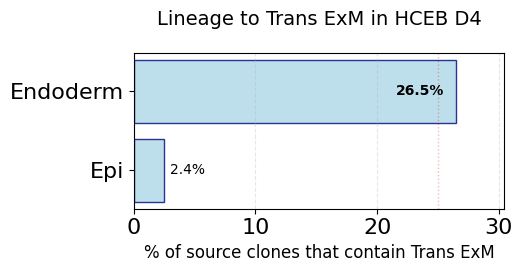

,Source,Target,Source Clones,Target Clones,Shared Clones,Clones with Both,Percentage (shared/source),Ratio (shared/source),Shared Clone IDs,Clones with Both IDs
0,Endoderm,Trans ExM,117,303,31,31,26.495726,31/117,"[clone_1998, clone_151, clone_667, clone_918, ...","[clone_1998, clone_151, clone_667, clone_918, ..."
1,Epi,Trans ExM,1143,303,28,28,2.449694,28/1143,"[clone_6, clone_390, clone_1531, clone_480, cl...","[clone_6, clone_390, clone_1531, clone_480, cl..."


In [10]:
# Helper functions are defined in the embedded 05_lineage.py section above.
visualize_sources_to_B(
    larry_d4,
    'CellType_short',
    ['Endoderm', 'Epi'],
    'Trans ExM',
    figsize=(5.5, 3),
    fig_title='Lineage to Trans ExM in HCEB D4',
    save_path=fig_dir / 'd4_hceb_lineage_to_trans_exm.pdf'
)

ANALYSIS: How many clones of different sources go to Trans ExM?
Target cell type: Trans ExM (303 clones)
Metric: (shared clones between source and B) / (source clones)

RESULTS (sorted by percentage, highest first):
    Source  Source Clones  Shared Clones  Percentage (shared/source) Ratio (shared/source)
CDX2+ Hypo             57             13                       22.81                 13/57
       Epi           1143             28                        2.45               28/1143
Figure saved to results/figures/312_larry_clonality/d4_hceb_lineage_to_trans_exm_sub.pdf


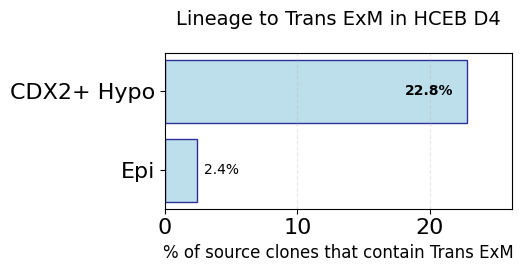

,Source,Target,Source Clones,Target Clones,Shared Clones,Clones with Both,Percentage (shared/source),Ratio (shared/source),Shared Clone IDs,Clones with Both IDs
0,CDX2+ Hypo,Trans ExM,57,303,13,13,22.807018,13/57,"[clone_621, clone_251, clone_635, clone_1998, ...","[clone_621, clone_251, clone_635, clone_1998, ..."
1,Epi,Trans ExM,1143,303,28,28,2.449694,28/1143,"[clone_6, clone_390, clone_1531, clone_480, cl...","[clone_6, clone_390, clone_1531, clone_480, cl..."


In [11]:
# Helper functions are defined in the embedded 05_lineage.py section above.
visualize_sources_to_B(
    larry_d4,
    'CellType_short_sub',
    ['CDX2+ Hypo', 'Epi'],
    'Trans ExM',
    figsize=(5.5, 3),
    fig_title='Lineage to Trans ExM in HCEB D4',
    save_path=fig_dir / 'd4_hceb_lineage_to_trans_exm_sub.pdf'
)

Population figure saved to results/figures/312_larry_clonality/d4_endoderm_and_trans_exm.pdf


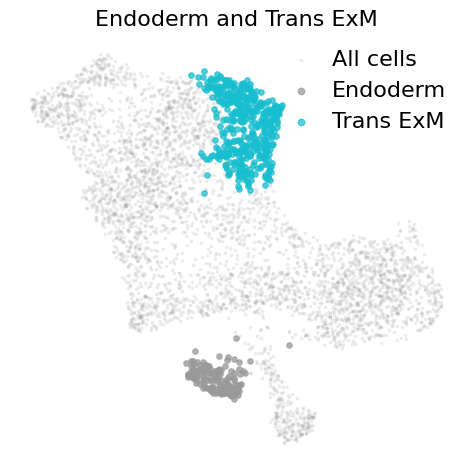

(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': 'Endoderm and Trans ExM'}>)

In [12]:
plot_AB_population(
    adata=larry_d4,
    celltype_label="CellType_short",
    celltype_A="Endoderm",
    celltype_B="Trans ExM",
    colorA=celltype_palette["Endoderm"],
    colorB=celltype_palette["Trans ExM"],
    figsize=(5, 5),
    point_size_bg=3,
    point_size_celltype=15,
    title="Endoderm and Trans ExM",
    save_path= fig_dir / 'd4_endoderm_and_trans_exm.pdf'
)

Recovering AB clone type from larry_clone...
Mixed clones containing both Endoderm and Trans ExM: 31
Endoderm-only cells: 105
Trans ExM-only cells: 382
Shared cells: 102
Clone sharing figure saved to results/figures/312_larry_clonality/d4_endoderm_to_trans_exm.pdf


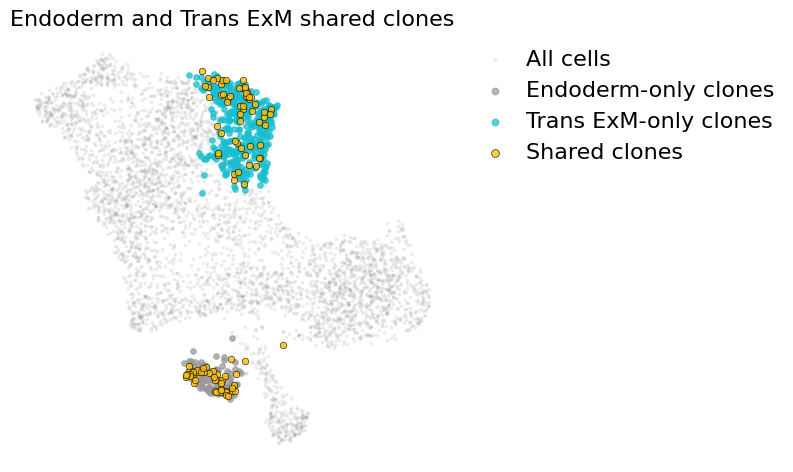

Endoderm-only cells: 105
Trans ExM-only cells: 382
Shared cells: 102


In [13]:
fig, ax, mixed_clone_ids = plot_AB_clone(
    adata=larry_d4,
    celltype_label="CellType_short",
    celltype_A="Endoderm",
    celltype_B="Trans ExM",
    colorA=celltype_palette["Endoderm"],
    colorB=celltype_palette["Trans ExM"],
    colorC="#FFC107",
    figsize=(8.2, 5),
    point_size_bg=3,
    point_size_celltype=15,
    point_size_shared=22,
    title="Endoderm and Trans ExM shared clones",
    legend_loc="upper left",
    legend_bbox_to_anchor=(1.02, 1),
    save_path= fig_dir / 'd4_endoderm_to_trans_exm.pdf'
)

Population figure saved to results/figures/312_larry_clonality/d4_cdx2_hypo_and_trans_exm.pdf


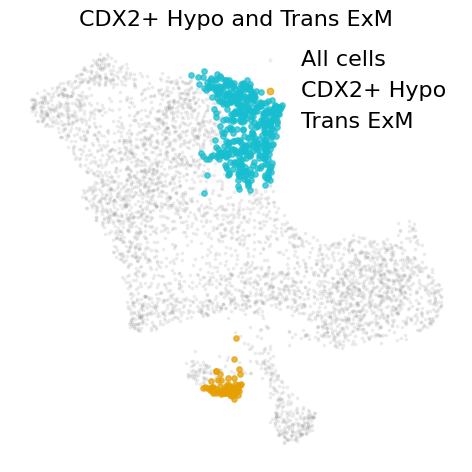

(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': 'CDX2+ Hypo and Trans ExM'}>)

In [14]:
plot_AB_population(
    adata=larry_d4,
    celltype_label="CellType_short_sub",
    celltype_A="CDX2+ Hypo",
    celltype_B="Trans ExM",
    colorA=celltype_palette["CDX2+ Hypo"],
    colorB=celltype_palette["Trans ExM"],
    figsize=(5, 5),
    point_size_bg=3,
    point_size_celltype=15,
    title="CDX2+ Hypo and Trans ExM",
    save_path= fig_dir / 'd4_cdx2_hypo_and_trans_exm.pdf'
)

Recovering AB clone type from larry_clone...
Mixed clones containing both CDX2+ Hypo and Trans ExM: 13
CDX2+ Hypo-only cells: 48
Trans ExM-only cells: 411
Shared cells: 46
Clone sharing figure saved to results/figures/312_larry_clonality/d4_cdx2_hypo_to_trans_exm.pdf


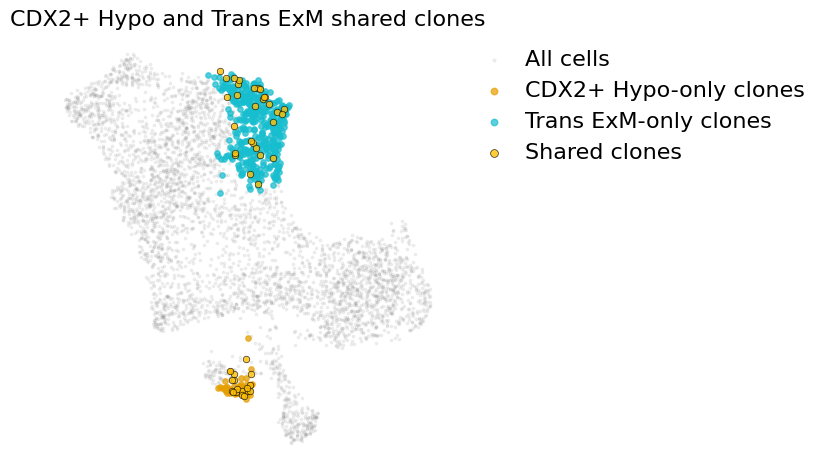

CDX2+ Hypo-only cells: 48
Trans ExM-only cells: 411
Shared cells: 46


In [15]:
fig, ax, mixed_clone_ids = plot_AB_clone(
    adata=larry_d4,
    celltype_label="CellType_short_sub",
    celltype_A="CDX2+ Hypo",
    celltype_B="Trans ExM",
    colorA=celltype_palette["CDX2+ Hypo"],
    colorB=celltype_palette["Trans ExM"],
    colorC="#FFC107",
    figsize=(8.2, 5),
    point_size_bg=3,
    point_size_celltype=15,
    point_size_shared=22,
    title="CDX2+ Hypo and Trans ExM shared clones",
    legend_loc="upper left",
    legend_bbox_to_anchor=(1.02, 1),
    save_path= fig_dir / 'd4_cdx2_hypo_to_trans_exm.pdf'
)

Population figure saved to results/figures/312_larry_clonality/d4_epi_and_trans_exm.pdf


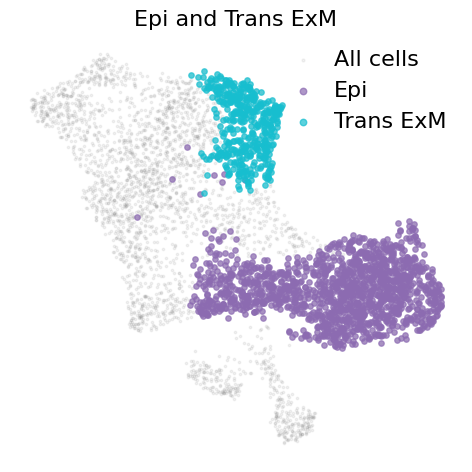

(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': 'Epi and Trans ExM'}>)

In [16]:
plot_AB_population(
    adata=larry_d4,
    celltype_label="CellType_short",
    celltype_A="Epi",
    celltype_B="Trans ExM",
    colorA=celltype_palette["Epi"],
    colorB=celltype_palette["Trans ExM"],
    figsize=(5, 5),
    point_size_bg=3,
    point_size_celltype=15,
    title="Epi and Trans ExM",
    save_path= fig_dir / 'd4_epi_and_trans_exm.pdf'
)

Recovering AB clone type from larry_clone...


Mixed clones containing both Epi and Trans ExM: 28
Epi-only cells: 1410
Trans ExM-only cells: 391
Shared cells: 92
Clone sharing figure saved to results/figures/312_larry_clonality/d4_epi_to_trans_exm.pdf


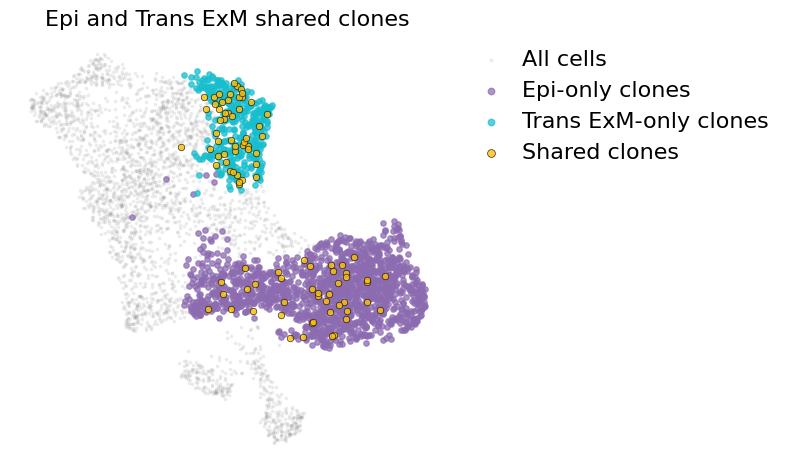

Epi-only cells: 1410
Trans ExM-only cells: 391
Shared cells: 92


In [17]:
fig, ax, mixed_clone_ids = plot_AB_clone(
    adata=larry_d4,
    celltype_label="CellType_short",
    celltype_A="Epi",
    celltype_B="Trans ExM",
    colorA=celltype_palette["Epi"],
    colorB=celltype_palette["Trans ExM"],
    colorC="#FFC107",
    figsize=(8.2, 5),
    point_size_bg=3,
    point_size_celltype=15,
    point_size_shared=22,
    title="Epi and Trans ExM shared clones",
    legend_loc="upper left",
    legend_bbox_to_anchor=(1.02, 1),
    save_path= fig_dir / 'd4_epi_to_trans_exm.pdf'
)

In [18]:
def visualize_all_populations_to_B(
    adata,
    column_to_check,
    target_B,
    source_cell_types=None,
    exclude_target=True,
    min_source_clones=1,
    fig_title=None,
    figsize=(7, 5),
    bar_color="lightblue",
    edgecolor="navy",
    alpha=0.8,
    show_ratio_label=True,
    show_percentage_label=True,
    save_path=None,
    dpi=300,
):
    """
    Analyze all populations to target_B and visualize:
    percentage = shared clones between source and target_B / source clones.

    Parameters
    ----------
    source_cell_types:
        If None, use all populations in column_to_check.
        If provided, only analyze those populations.
    exclude_target:
        Whether to exclude target_B from source populations.
    min_source_clones:
        Filter out source populations with fewer than this number of source clones.
    """

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    # ------------------------------------------------------------
    # Decide source populations
    # ------------------------------------------------------------
    if source_cell_types is None:
        source_cell_types = sorted(
            adata.obs[column_to_check]
            .dropna()
            .astype(str)
            .unique()
        )

    if exclude_target:
        source_cell_types = [x for x in source_cell_types if x != target_B]

    # ------------------------------------------------------------
    # Run analysis
    # ------------------------------------------------------------
    results_df = analyze_multiple_to_B(
        adata=adata,
        column_to_check=column_to_check,
        source_cell_types=source_cell_types,
        target_B=target_B,
    )

    # ------------------------------------------------------------
    # Filter low clone-number sources
    # ------------------------------------------------------------
    results_df = results_df[
        results_df["Source Clones"] >= min_source_clones
    ].copy()

    results_df = results_df.sort_values(
        "Percentage (shared/source)",
        ascending=False,
    ).reset_index(drop=True)

    if results_df.empty:
        raise ValueError(
            f"No source population has >= {min_source_clones} source clones."
        )

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    sources = results_df["Source"]
    percentages = results_df["Percentage (shared/source)"]
    y_pos = np.arange(len(sources))

    bars = ax.barh(
        y_pos,
        percentages,
        color=bar_color,
        edgecolor=edgecolor,
        alpha=alpha,
    )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(sources)
    ax.invert_yaxis()

    # yticklabels = ax.get_yticklabels()
    # for i, tick in enumerate(yticklabels):
    #     tick.set_color("black")
    #     tick.set_fontweight("bold" if i == 0 else "normal")

    ax.set_xlabel(f"% of source clones that contain {target_B}", fontsize=12)

    max_perc = percentages.max()
    x_max = max(max_perc * 1.25, 5)
    ax.set_xlim(0, x_max)

    if fig_title is None:
        fig_title = f"All source populations shared with {target_B}"

    ax.set_title(fig_title, fontsize=14, pad=15)

    # ------------------------------------------------------------
    # Add labels
    # ------------------------------------------------------------
    # for i, (bar, percentage, source_clones, shared_clones) in enumerate(
    #     zip(
    #     bars,
    #     percentages,
    #     results_df["Source Clones"],
    #     results_df["Shared Clones"],
    #     )
    #     ):
        
    #     width = bar.get_width()
    #     y = bar.get_y() + bar.get_height() / 2

    # label_parts = []

    # if show_percentage_label:
    #     label_parts.append(f"{percentage:.1f}%")

    # if show_ratio_label:
    #     label_parts.append(f"({shared_clones}/{source_clones})")

    # label = " ".join(label_parts)

    # # Always put label outside the bar
    # label_x = width + x_max * 0.015

    # # Only top1 is bold; all others are black regular
    # if i == 0:
    #     fontweight = "bold"
    # else:
    #     fontweight = "normal"

    # ax.text(
    #     label_x,
    #     y,
    #     label,
    #     ha="left",
    #     va="center",
    #     color="black",
    #     fontsize=10,
    #     fontweight=fontweight,
    # )

    # ------------------------------------------------------------
    # Reference lines
    # ------------------------------------------------------------
    ax.grid(True, axis="x", alpha=0.3, linestyle="--")

    for perc in [25, 50, 75]:
        if perc <= max_perc:
            ax.axvline(
                x=perc,
                color="red",
                linestyle=":",
                alpha=0.25,
                linewidth=1,
            )

    # ax.spines["top"].set_visible(False)
    # ax.spines["right"].set_visible(False)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Figure saved to {save_path}")

    plt.show()

    return results_df

ANALYSIS: How many clones of different sources go to Trans ExM?
Target cell type: Trans ExM (303 clones)
Metric: (shared clones between source and B) / (source clones)

RESULTS (sorted by percentage, highest first):
  Source  Source Clones  Shared Clones  Percentage (shared/source) Ratio (shared/source)
Endoderm            117             31                       26.50                31/117
      HE            331             47                       14.20                47/331
 Adv Mes            796             96                       12.06                96/796
Nasc Mes            214             19                        8.88                19/214
     PGC            214             18                        8.41                18/214
     Epi           1143             28                        2.45               28/1143
     Amn            223              5                        2.24                 5/223


Figure saved to results/figures/312_larry_clonality/d4_all_populations_to_trans_exm.pdf


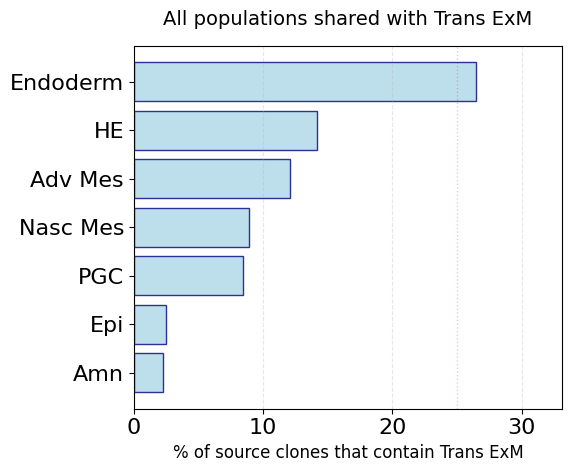

In [19]:
results_all_to_trans = visualize_all_populations_to_B(
    adata=larry_d4,
    column_to_check="CellType_short",
    target_B="Trans ExM",
    min_source_clones=3,
    fig_title="All populations shared with Trans ExM",
    figsize=(6, 5),
    save_path=fig_dir / "d4_all_populations_to_trans_exm.pdf",
)        

ANALYSIS: How many clones of different sources go to Adv Mes?
Target cell type: Adv Mes (796 clones)
Metric: (shared clones between source and B) / (source clones)



RESULTS (sorted by percentage, highest first):
   Source  Source Clones  Shared Clones  Percentage (shared/source) Ratio (shared/source)
       HE            331            151                       45.62               151/331
 Endoderm            117             42                       35.90                42/117
Trans ExM            303             96                       31.68                96/303
      PGC            214             67                       31.31                67/214
 Nasc Mes            214             41                       19.16                41/214
      Amn            223             31                       13.90                31/223
      Epi           1143             93                        8.14               93/1143
Figure saved to results/figures/312_larry_clonality/d4_all_populations_to_adv_mes.pdf


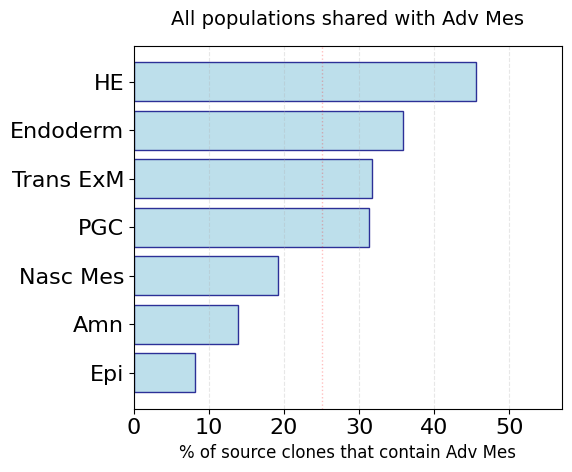

In [20]:
results_all_to_trans = visualize_all_populations_to_B(
    adata=larry_d4,
    column_to_check="CellType_short",
    target_B="Adv Mes",
    min_source_clones=3,
    fig_title="All populations shared with Adv Mes",
    figsize=(6, 5),
    save_path=fig_dir / "d4_all_populations_to_adv_mes.pdf",
)        

ANALYSIS: How many clones of different sources go to Nasc Mes?
Target cell type: Nasc Mes (214 clones)
Metric: (shared clones between source and B) / (source clones)

RESULTS (sorted by percentage, highest first):
   Source  Source Clones  Shared Clones  Percentage (shared/source) Ratio (shared/source)
Trans ExM            303             19                        6.27                19/303
      PGC            214             13                        6.07                13/214
      Amn            223             13                        5.83                13/223
  Adv Mes            796             41                        5.15                41/796
 Endoderm            117              5                        4.27                 5/117
       HE            331             14                        4.23                14/331
      Epi           1143             46                        4.02               46/1143
Figure saved to results/figures/312_larry_clonality/d4_all_populat

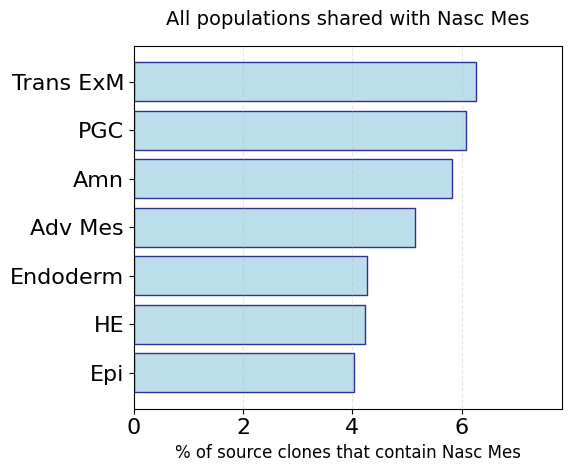

In [21]:
results_all_to_trans = visualize_all_populations_to_B(
    adata=larry_d4,
    column_to_check="CellType_short",
    target_B="Nasc Mes",
    min_source_clones=3,
    fig_title="All populations shared with Nasc Mes",
    figsize=(6, 5),
    save_path=fig_dir / "d4_all_populations_to_nasc_mes.pdf",
)        

In [22]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(
    dpi=100,
    dpi_save=600,
    facecolor="white",
    frameon=False,
    vector_friendly=True,
)


ANALYSIS: How many clones of different sources go to HE?
Target cell type: HE (331 clones)
Metric: (shared clones between source and B) / (source clones)

RESULTS (sorted by percentage, highest first):
   Source  Source Clones  Shared Clones  Percentage (shared/source) Ratio (shared/source)
 Endoderm            117             27                       23.08                27/117
  Adv Mes            796            151                       18.97               151/796
Trans ExM            303             47                       15.51                47/303
      PGC            214             28                       13.08                28/214
      Amn            223             15                        6.73                15/223
 Nasc Mes            214             14                        6.54                14/214
      Epi           1143             26                        2.27               26/1143


Figure saved to results/figures/312_larry_clonality/d4_all_populations_to_he.pdf


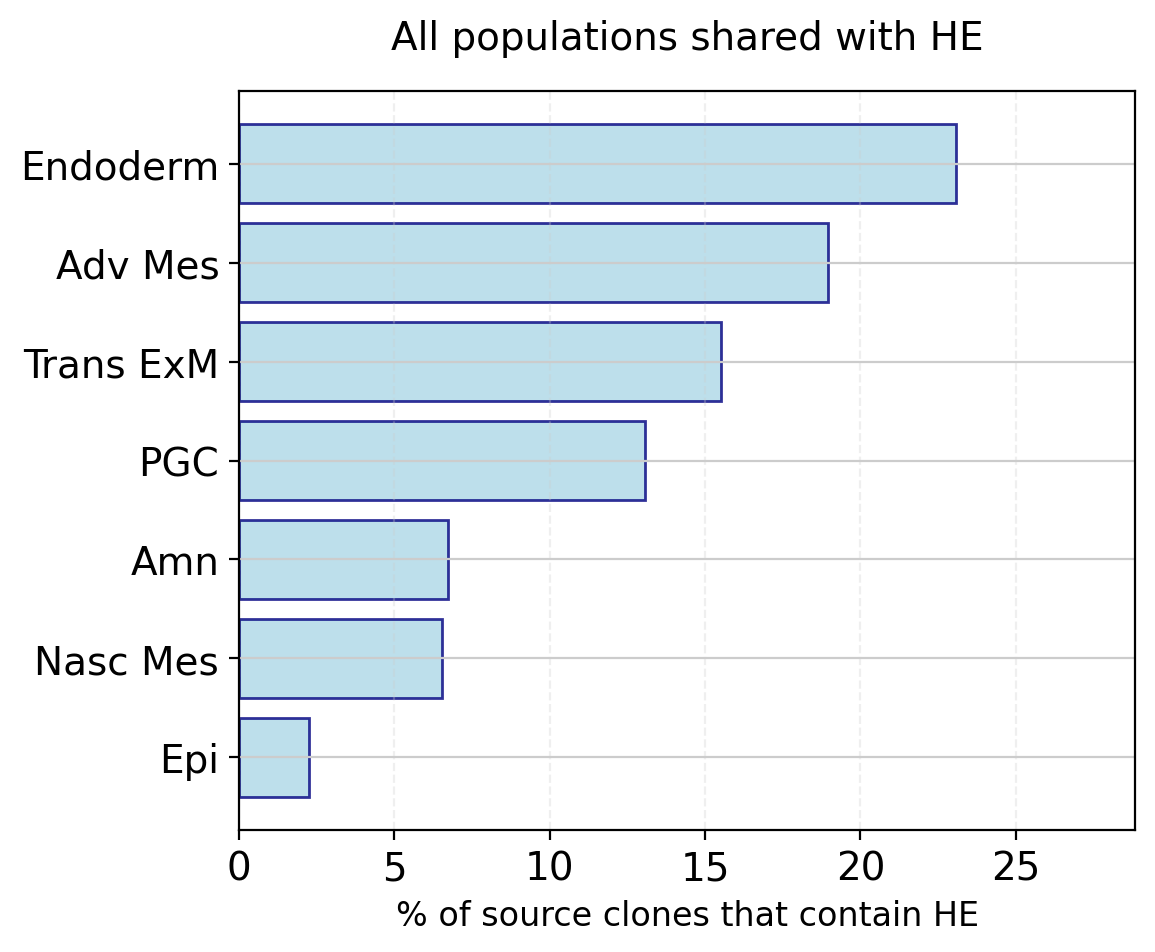

In [23]:
results_all_to_trans = visualize_all_populations_to_B(
    adata=larry_d4,
    column_to_check="CellType_short",
    target_B="HE",
    min_source_clones=3,
    fig_title="All populations shared with HE",
    figsize=(6, 5),
    save_path=fig_dir / "d4_all_populations_to_he.pdf",
)        

In [24]:
candidate_paths = [
    Path("/mnt/yiming/nfs_share/projects/hypoblast/results/processed/larry_d7_revised_labels.h5ad"),
]

larry_d7_path = next((p for p in candidate_paths if p.exists()), None)
if larry_d7_path is None:
    raise FileNotFoundError(
        "Could not find the Day 7 LARRY h5ad file. Checked:\n" +
        "\n".join(str(p) for p in candidate_paths)
    )

larry_d7 = sc.read_h5ad(larry_d7_path)
print(f"Loaded: {larry_d7_path}")
print(larry_d7)

celltype_key = 'CellType_short'

Loaded: /mnt/yiming/nfs_share/projects/hypoblast/results/processed/larry_d7_revised_labels.h5ad
AnnData object with n_obs × n_vars = 3824 × 29701
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden', 'larry_barcode', 'larry_clone', 'CellType_revised_short', 'CellType_revised', 'CellType_revised_full', 'CellType_short'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'CellType_man_colors', 'CellType_revised_short_colors', 'CellType_short_colors', 'Tyser_label_colors', 'Tyser_label_v2_colors', 'hembry

In [25]:
clone_key = "larry_clone"
required_obs = [celltype_key, clone_key]
missing_obs = [x for x in required_obs if x not in larry_d7.obs.columns]
if missing_obs:
    raise KeyError(f"Missing required obs columns: {missing_obs}")

qc_summary = pd.Series({
    "n_cells": larry_d7.n_obs,
    "n_genes": larry_d7.n_vars,
    "n_annotated_cells": larry_d7.obs[celltype_key].notna().sum(),
    "n_clone_assigned_cells": larry_d7.obs[clone_key].notna().sum(),
    "n_unique_clones": larry_d7.obs[clone_key].dropna().astype(str).nunique(),
}, name="value").to_frame()
qc_summary.to_csv(table_dir / "larry_d7_basic_qc.csv")
qc_summary

,value
n_cells,3824
n_genes,29701
n_annotated_cells,3824
n_clone_assigned_cells,3824
n_unique_clones,1682


In [26]:
clone_sizes = (
    larry_d7.obs.loc[larry_d7.obs[clone_key].notna(), clone_key]
    .astype(str)
    .value_counts()
    .rename_axis("clone_id")
    .rename("n_cells")
    .to_frame()
)
clone_sizes.to_csv(table_dir / "larry_d7_clone_sizes.csv")
clone_sizes.describe()

,n_cells
count,1682.000000
mean,2.273484
std,4.303769
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,76.000000


In [27]:
clonality_report_dir = fig_dir / 'd7_full_clonality_report'

clonality_results = generate_full_clone_report(
    larry_d7,
    output_dir=str(clonality_report_dir),
    dataset_name='larry_d7',
    return_data=True,
)

# Save the clone-sharing Jaccard matrix as a table.
larry_d7_jaccard_df = pd.DataFrame(
    clonality_results['jaccard_matrix'],
    index=clonality_results['cell_types'],
    columns=clonality_results['cell_types'],
)
larry_d7_jaccard_df.to_csv(table_dir / 'larry_d7_celltype_clone_jaccard_matrix.csv')
larry_d7_jaccard_df

Clonality Report: larry_d7
--------------------------------------------------
Total clones: 1682
Gini coefficient: 0.4895
Shannon entropy: 9.7863
Normalized entropy: 0.9132
Simpson diversity: 0.9973
Expansion index: 0.6901


,Adv Mes,Amn,EMP,Emerg Mes,Endoderm,Epi,Ery,HE,PGC,PS,Trans ExM
Adv Mes,1.000000,0.079909,0.050909,0.003766,0.016514,0.032534,0.0,0.233333,0.028777,0.051971,0.010859
Amn,0.079909,1.000000,0.014493,0.006787,0.004310,0.017787,0.0,0.058442,0.008333,0.024641,0.002141
EMP,0.050909,0.014493,1.000000,0.000000,0.020833,0.013793,0.0,0.088123,0.008696,0.056452,0.005310
Emerg Mes,0.003766,0.006787,0.000000,1.000000,0.019231,0.020000,0.0,0.004202,0.000000,0.011765,0.000000
Endoderm,0.016514,0.004310,0.020833,0.019231,1.000000,0.000000,0.0,0.023622,0.000000,0.019048,0.003690
Epi,0.032534,0.017787,0.013793,0.020000,0.000000,1.000000,0.0,0.033445,0.000000,0.012987,0.001689
Ery,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000
HE,0.233333,0.058442,0.088123,0.004202,0.023622,0.033445,0.0,1.000000,0.018315,0.065455,0.008287
PGC,0.028777,0.008333,0.008696,0.000000,0.000000,0.000000,0.0,0.018315,1.000000,0.016260,0.005367
PS,0.051971,0.024641,0.056452,0.011765,0.019048,0.012987,0.0,0.065455,0.016260,1.000000,0.003478


ANALYSIS: How many clones of different sources go to Trans ExM?
Target cell type: Trans ExM (507 clones)
Metric: (shared clones between source and B) / (source clones)

RESULTS (sorted by percentage, highest first):
  Source  Source Clones  Shared Clones  Percentage (shared/source) Ratio (shared/source)
Endoderm             37              2                        5.41                  2/37
     Epi             86              1                        1.16                  1/86
Figure saved to results/figures/312_larry_clonality/d7_hceb_lineage_to_trans_exm.pdf


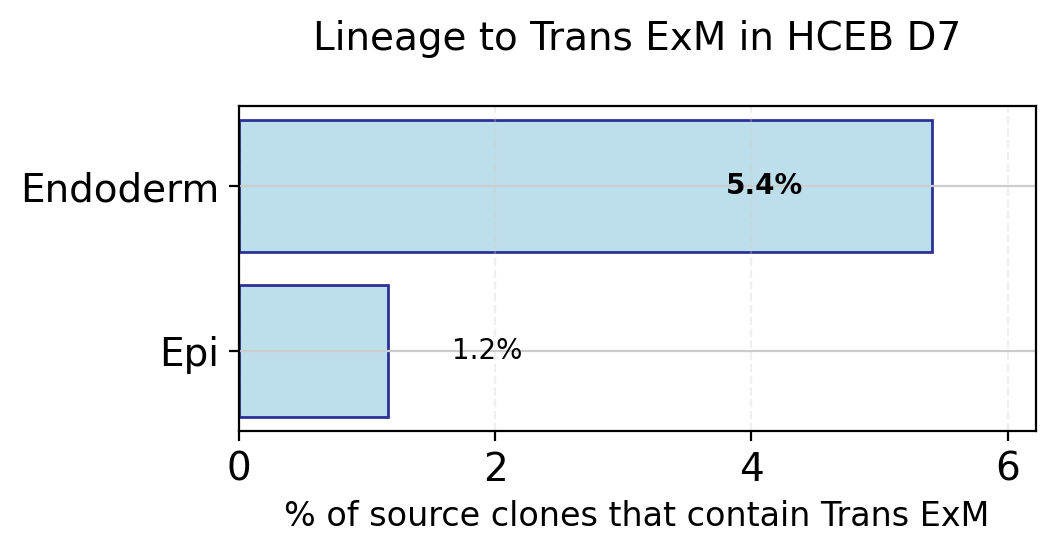

,Source,Target,Source Clones,Target Clones,Shared Clones,Clones with Both,Percentage (shared/source),Ratio (shared/source),Shared Clone IDs,Clones with Both IDs
0,Endoderm,Trans ExM,37,507,2,2,5.405405,2/37,"[clone_249, clone_773]","[clone_249, clone_773]"
1,Epi,Trans ExM,86,507,1,1,1.162791,1/86,[clone_541],[clone_541]


In [28]:
# Helper functions are defined in the embedded 05_lineage.py section above.
visualize_sources_to_B(
    larry_d7,
    'CellType_short',
    ['Endoderm', 'Epi'],
    'Trans ExM',
    figsize=(5.5, 3),
    fig_title='Lineage to Trans ExM in HCEB D7',
    save_path=fig_dir / 'd7_hceb_lineage_to_trans_exm.pdf'
)

Population figure saved to results/figures/312_larry_clonality/d7_endoderm_and_trans_exm.pdf


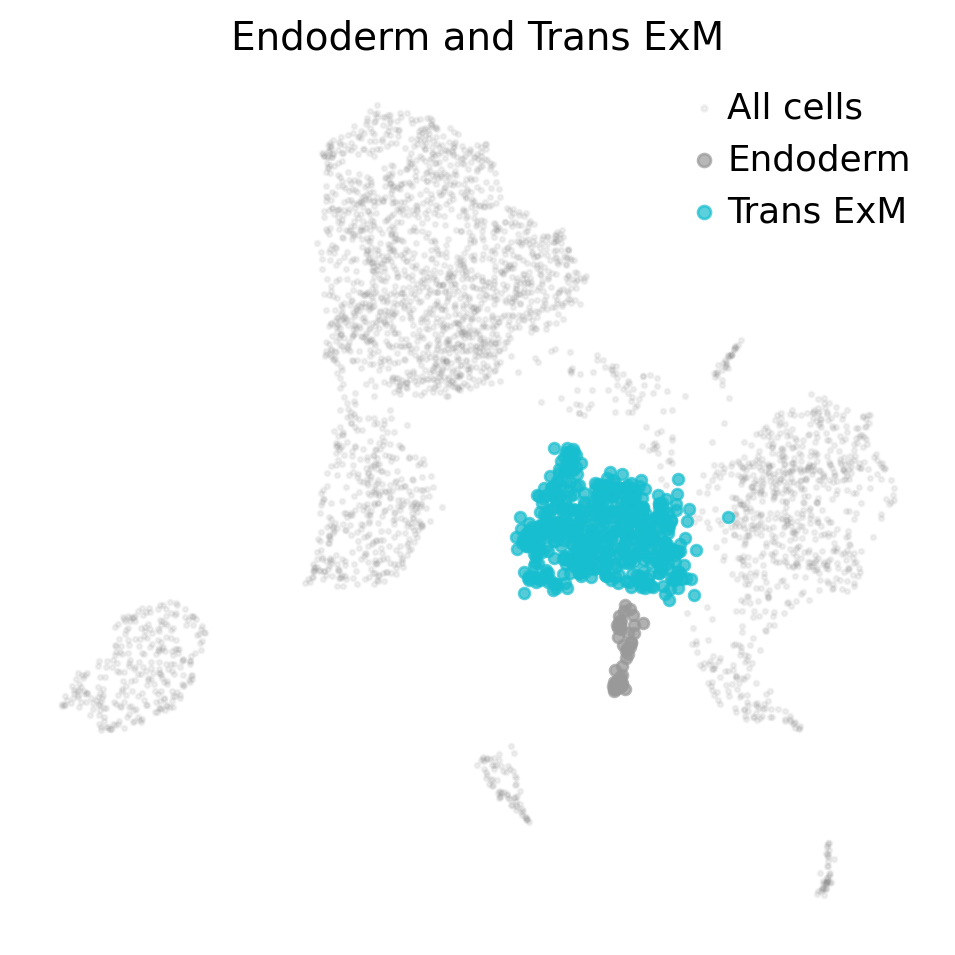

(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': 'Endoderm and Trans ExM'}>)

In [29]:
plot_AB_population(
    adata=larry_d7,
    celltype_label="CellType_short",
    celltype_A="Endoderm",
    celltype_B="Trans ExM",
    colorA=celltype_palette["Endoderm"],
    colorB=celltype_palette["Trans ExM"],
    figsize=(5, 5),
    point_size_bg=3,
    point_size_celltype=15,
    title="Endoderm and Trans ExM",
    save_path= fig_dir / 'd7_endoderm_and_trans_exm.pdf'
)

Recovering AB clone type from larry_clone...
Mixed clones containing both Endoderm and Trans ExM: 2
Endoderm-only cells: 44
Trans ExM-only cells: 517
Shared cells: 4
Clone sharing figure saved to results/figures/312_larry_clonality/d7_endoderm_to_trans_exm.pdf


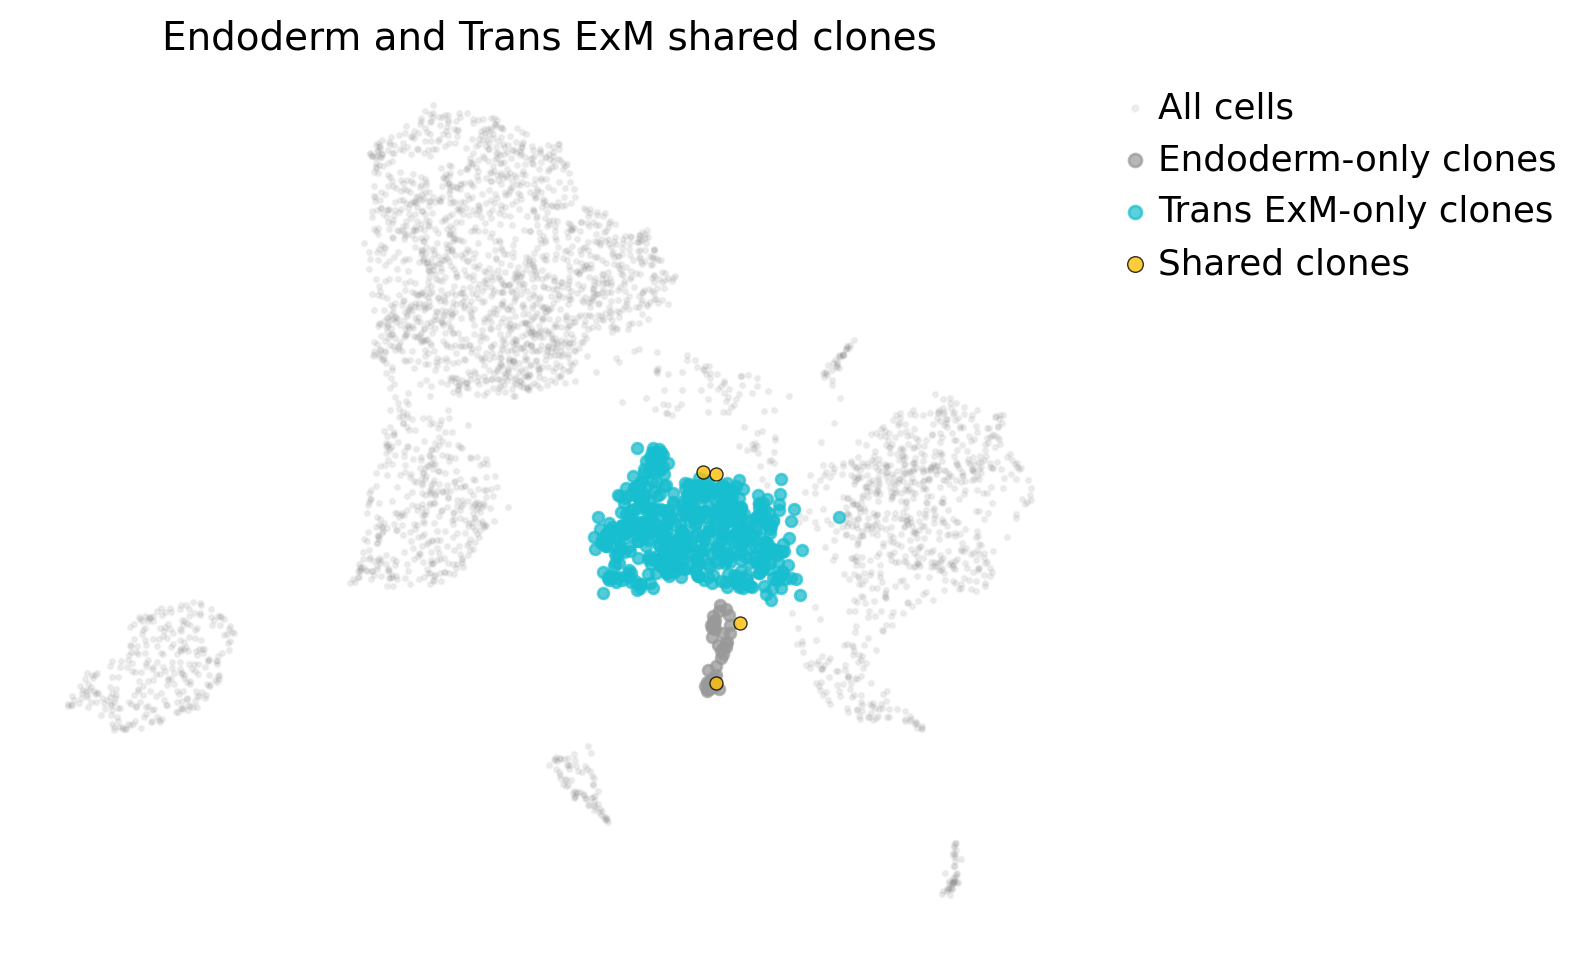

Endoderm-only cells: 44
Trans ExM-only cells: 517
Shared cells: 4


In [30]:
fig, ax, mixed_clone_ids = plot_AB_clone(
    adata=larry_d7,
    celltype_label="CellType_short",
    celltype_A="Endoderm",
    celltype_B="Trans ExM",
    colorA=celltype_palette["Endoderm"],
    colorB=celltype_palette["Trans ExM"],
    colorC="#FFC107",
    figsize=(8.2, 5),
    point_size_bg=3,
    point_size_celltype=15,
    point_size_shared=22,
    title="Endoderm and Trans ExM shared clones",
    legend_loc="upper left",
    legend_bbox_to_anchor=(1.02, 1),
    save_path= fig_dir / 'd7_endoderm_to_trans_exm.pdf'
)

Population figure saved to results/figures/312_larry_clonality/d7_epi_and_trans_exm.pdf


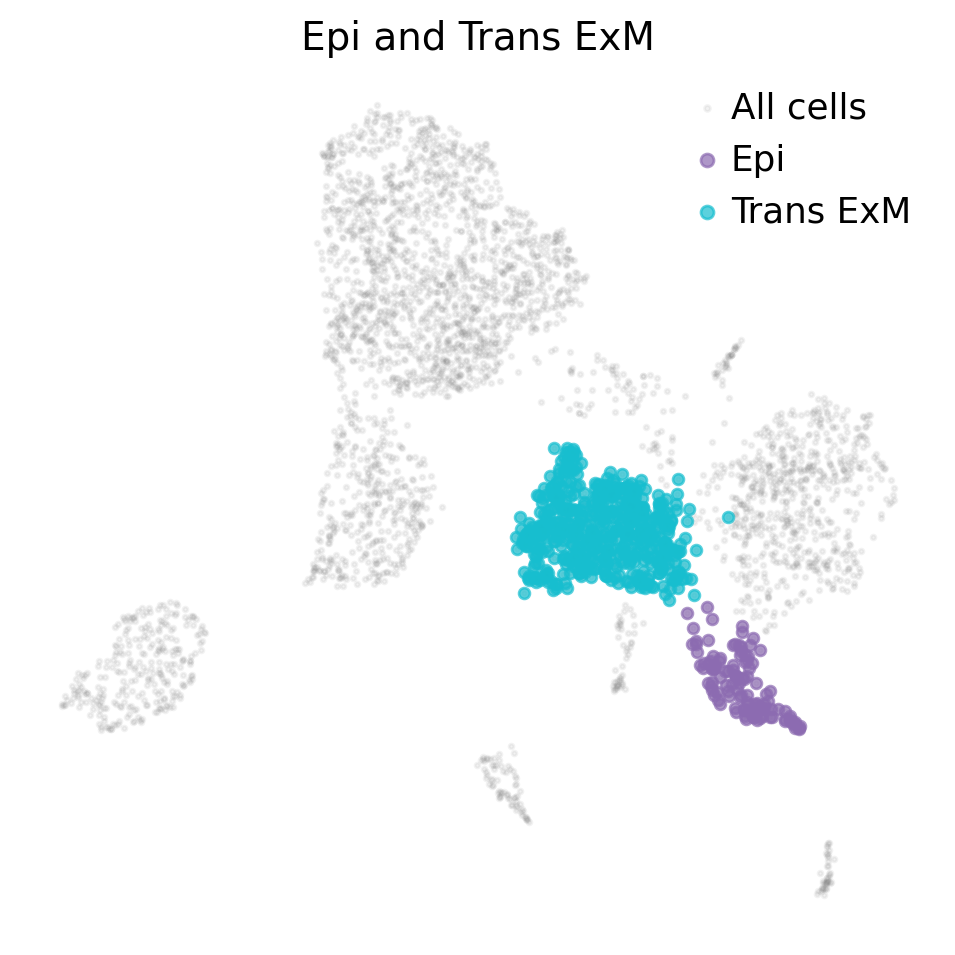

(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': 'Epi and Trans ExM'}>)

In [31]:
plot_AB_population(
    adata=larry_d7,
    celltype_label="CellType_short",
    celltype_A="Epi",
    celltype_B="Trans ExM",
    colorA=celltype_palette["Epi"],
    colorB=celltype_palette["Trans ExM"],
    figsize=(5, 5),
    point_size_bg=3,
    point_size_celltype=15,
    title="Epi and Trans ExM",
    save_path= fig_dir / 'd7_epi_and_trans_exm.pdf'
)

Recovering AB clone type from larry_clone...
Mixed clones containing both Epi and Trans ExM: 1
Epi-only cells: 108
Trans ExM-only cells: 518
Shared cells: 2
Clone sharing figure saved to results/figures/312_larry_clonality/d7_epi_to_trans_exm.pdf


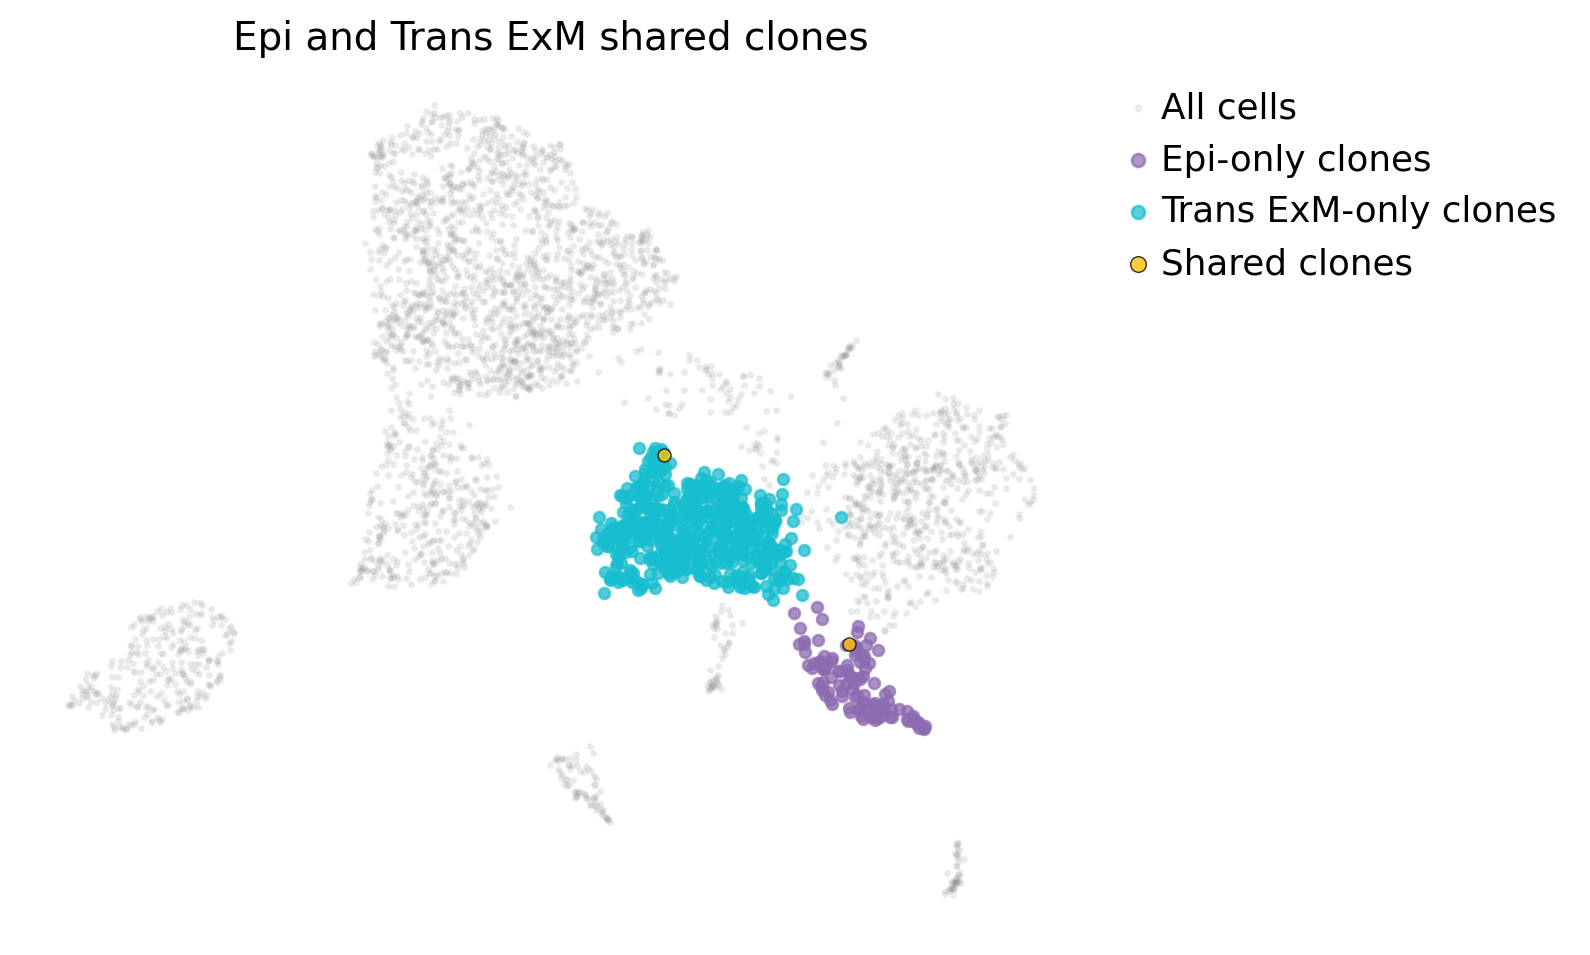

Epi-only cells: 108
Trans ExM-only cells: 518
Shared cells: 2


In [32]:
fig, ax, mixed_clone_ids = plot_AB_clone(
    adata=larry_d7,
    celltype_label="CellType_short",
    celltype_A="Epi",
    celltype_B="Trans ExM",
    colorA=celltype_palette["Epi"],
    colorB=celltype_palette["Trans ExM"],
    colorC="#FFC107",
    figsize=(8.2, 5),
    point_size_bg=3,
    point_size_celltype=15,
    point_size_shared=22,
    title="Epi and Trans ExM shared clones",
    legend_loc="upper left",
    legend_bbox_to_anchor=(1.02, 1),
    save_path= fig_dir / 'd7_epi_to_trans_exm.pdf'
)

ANALYSIS: How many clones of different sources go to EMP?
Target cell type: EMP (61 clones)
Metric: (shared clones between source and B) / (source clones)

RESULTS (sorted by percentage, highest first):
   Source  Source Clones  Shared Clones  Percentage (shared/source) Ratio (shared/source)
       HE            223             23                       10.31                23/223
Trans ExM            507              3                        0.59                 3/507
Figure saved to results/figures/312_larry_clonality/d7_hceb_lineage_to_emp.pdf


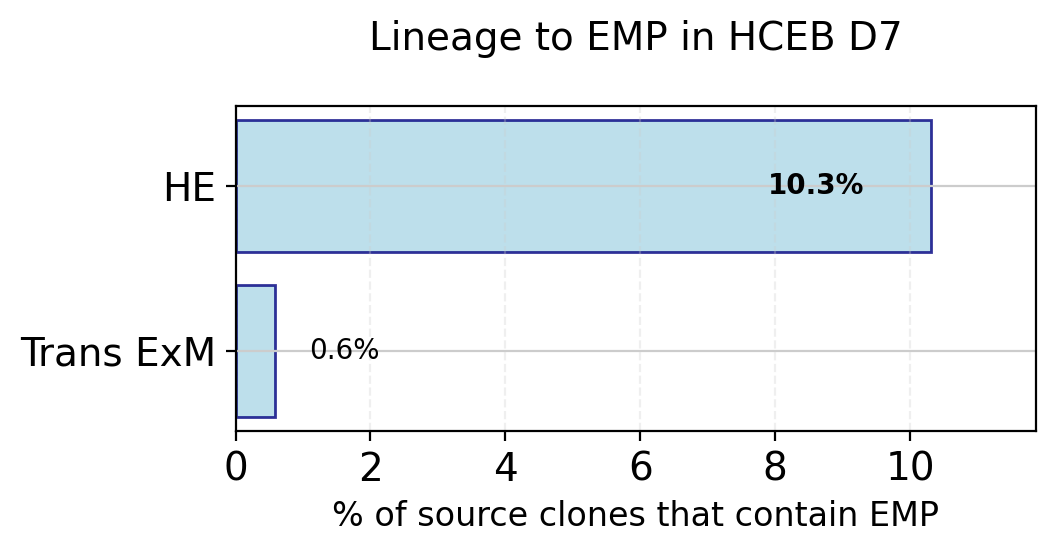

,Source,Target,Source Clones,Target Clones,Shared Clones,Clones with Both,Percentage (shared/source),Ratio (shared/source),Shared Clone IDs,Clones with Both IDs
0,HE,EMP,223,61,23,23,10.313901,23/223,"[clone_97, clone_190, clone_74, clone_118, clo...","[clone_97, clone_190, clone_74, clone_118, clo..."
1,Trans ExM,EMP,507,61,3,3,0.591716,3/507,"[clone_74, clone_862, clone_266]","[clone_74, clone_862, clone_266]"


In [33]:
# Helper functions are defined in the embedded 05_lineage.py section above.
visualize_sources_to_B(
    larry_d7,
    'CellType_short',
    ['HE', 'Trans ExM'],
    'EMP',
    figsize=(5.5, 3),
    fig_title='Lineage to EMP in HCEB D7',
    save_path=fig_dir / 'd7_hceb_lineage_to_emp.pdf'
)

Population figure saved to results/figures/312_larry_clonality/d7_he_and_emp.pdf


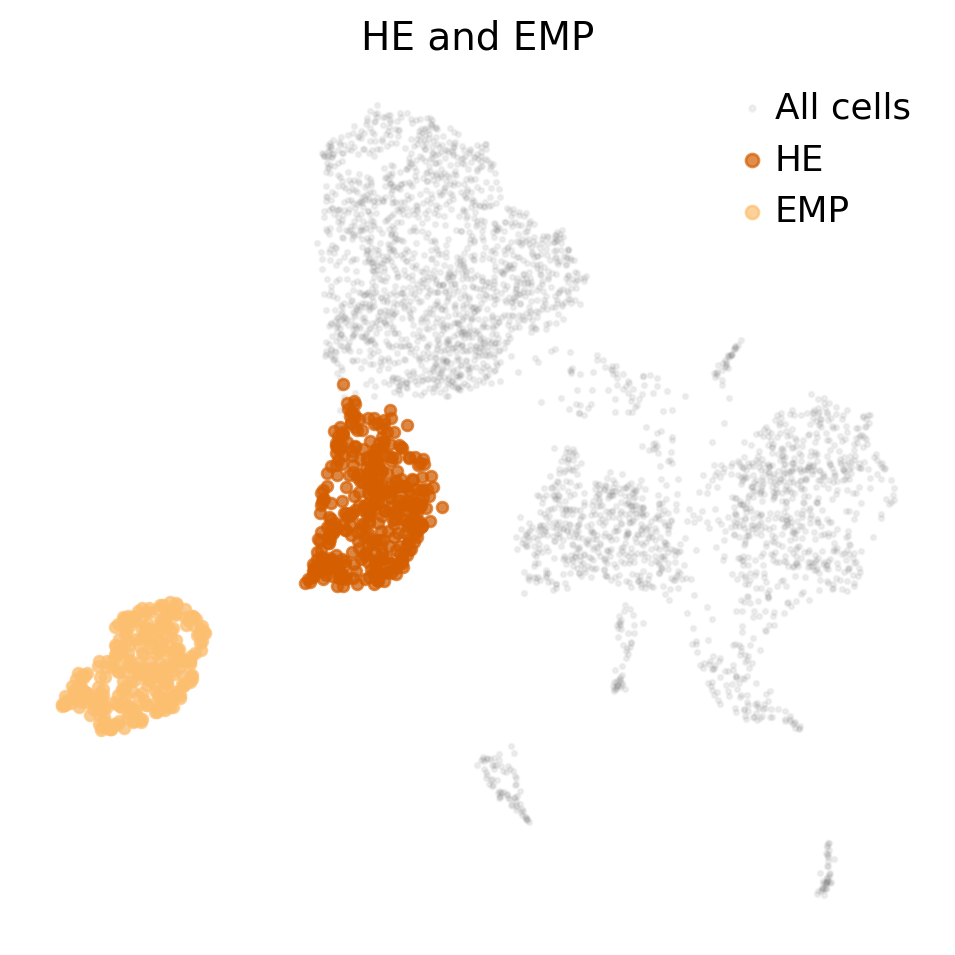

(<Figure size 500x500 with 1 Axes>, <Axes: title={'center': 'HE and EMP'}>)

In [34]:
plot_AB_population(
    adata=larry_d7,
    celltype_label="CellType_short",
    celltype_A="HE",
    celltype_B="EMP",
    colorA=celltype_palette["HE"],
    colorB=celltype_palette["EMP"],
    figsize=(5, 5),
    point_size_bg=3,
    point_size_celltype=15,
    title="HE and EMP",
    save_path= fig_dir / 'd7_he_and_emp.pdf'
)

Recovering AB clone type from larry_clone...


Mixed clones containing both HE and EMP: 23
HE-only cells: 291
EMP-only cells: 125
Shared cells: 250
Clone sharing figure saved to results/figures/312_larry_clonality/d7_he_to_emp.pdf


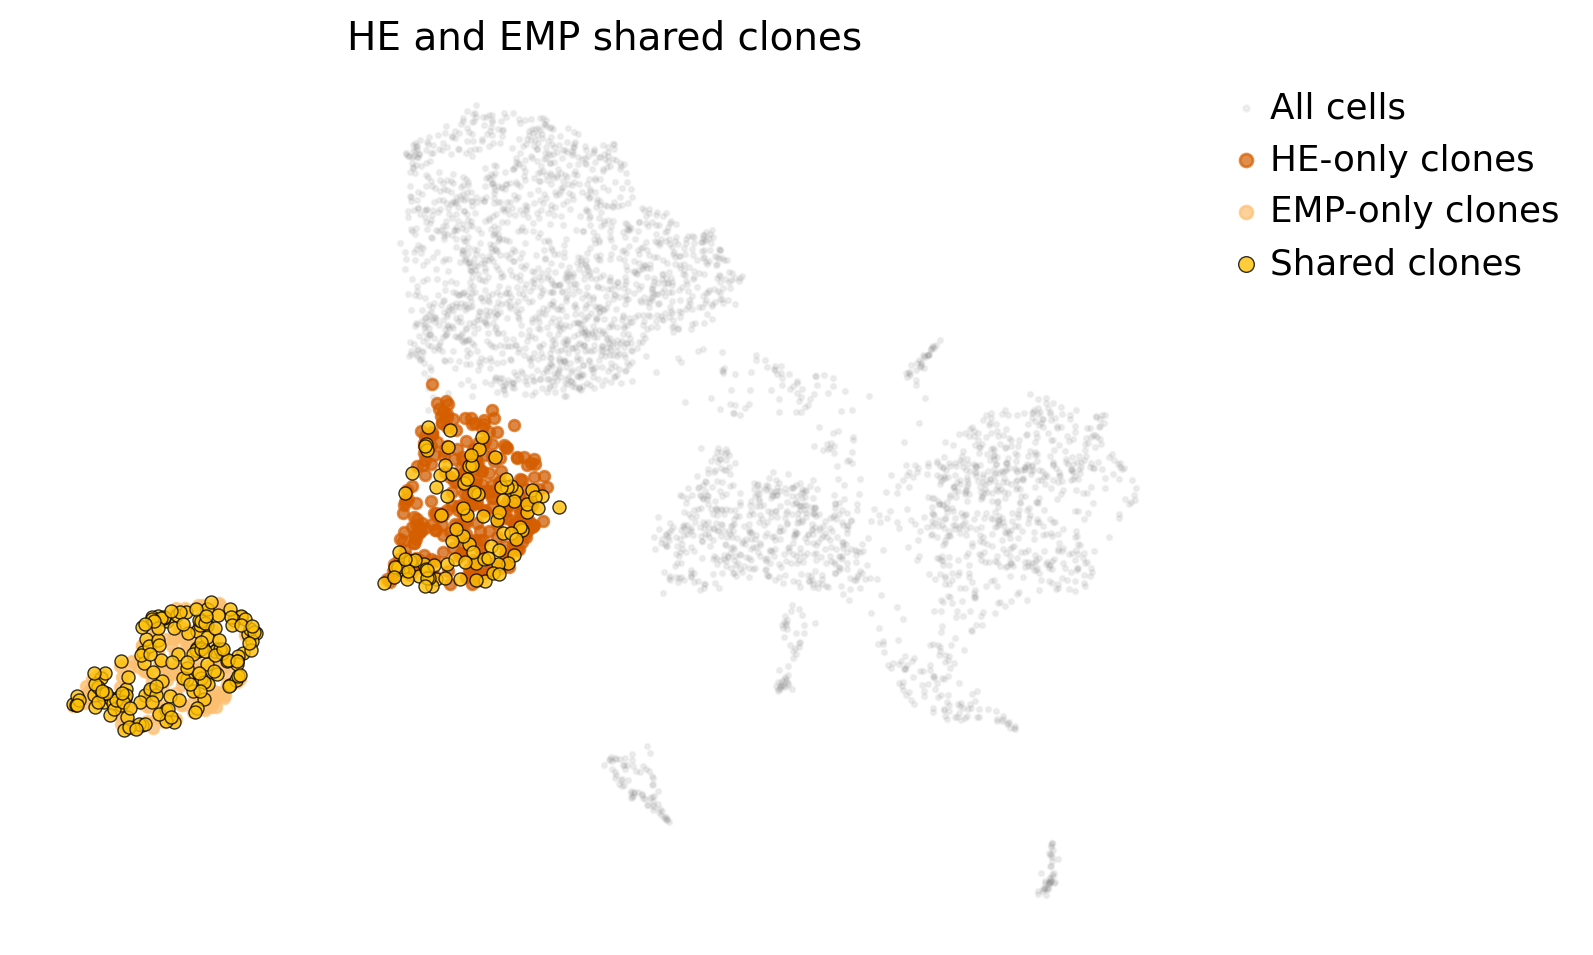

HE-only cells: 291
EMP-only cells: 125
Shared cells: 250


In [35]:
fig, ax, mixed_clone_ids = plot_AB_clone(
    adata=larry_d7,
    celltype_label="CellType_short",
    celltype_A="HE",
    celltype_B="EMP",
    colorA=celltype_palette["HE"],
    colorB=celltype_palette["EMP"],
    colorC="#FFC107",
    figsize=(8.2, 5),
    point_size_bg=3,
    point_size_celltype=15,
    point_size_shared=22,
    title="HE and EMP shared clones",
    legend_loc="upper left",
    legend_bbox_to_anchor=(1.02, 1),
    save_path= fig_dir / 'd7_he_to_emp.pdf'
)

Population figure saved to results/figures/312_larry_clonality/d7_trans_exm_and_emp.pdf


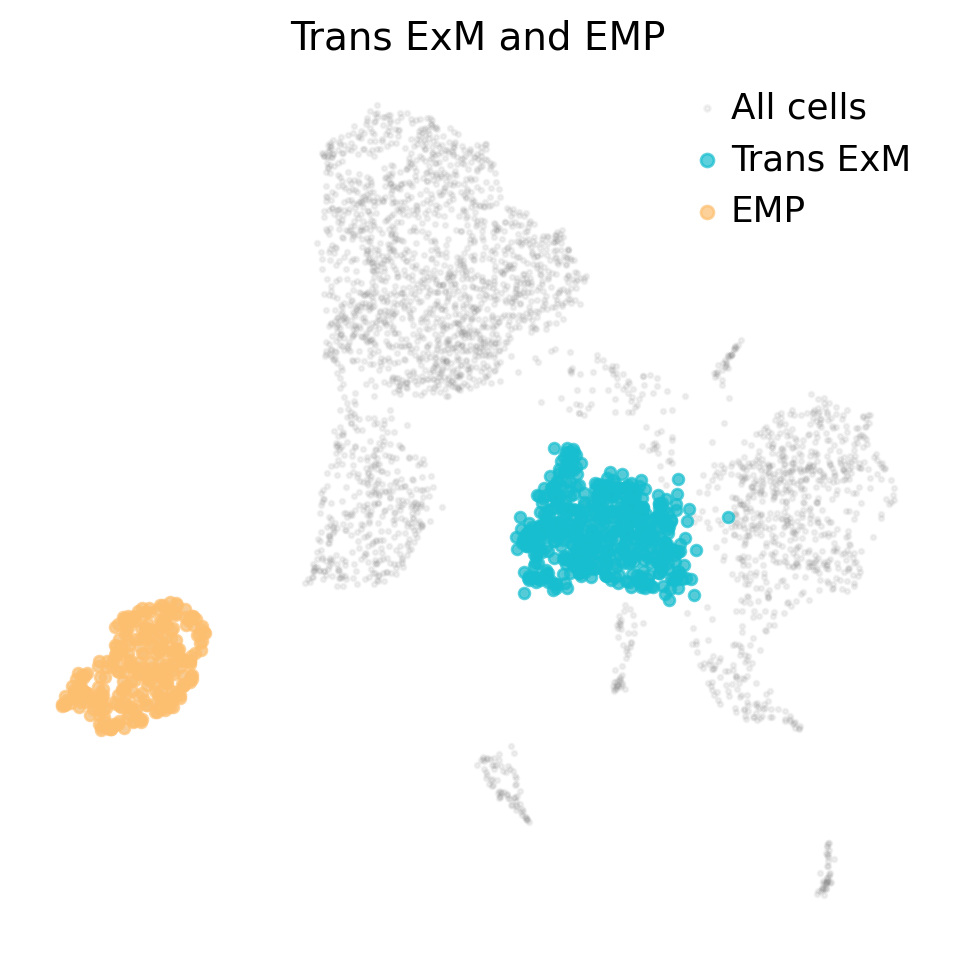

(<Figure size 500x500 with 1 Axes>,
 <Axes: title={'center': 'Trans ExM and EMP'}>)

In [36]:
plot_AB_population(
    adata=larry_d7,
    celltype_label="CellType_short",
    celltype_A="Trans ExM",
    celltype_B="EMP",
    colorA=celltype_palette["Trans ExM"],
    colorB=celltype_palette["EMP"],
    figsize=(5, 5),
    point_size_bg=3,
    point_size_celltype=15,
    title="Trans ExM and EMP",
    save_path= fig_dir / 'd7_trans_exm_and_emp.pdf'
)

Recovering AB clone type from larry_clone...


Mixed clones containing both Trans ExM and EMP: 3
Trans ExM-only cells: 513
EMP-only cells: 225
Shared cells: 65
Clone sharing figure saved to results/figures/312_larry_clonality/d7_trans_exm_to_emp.pdf


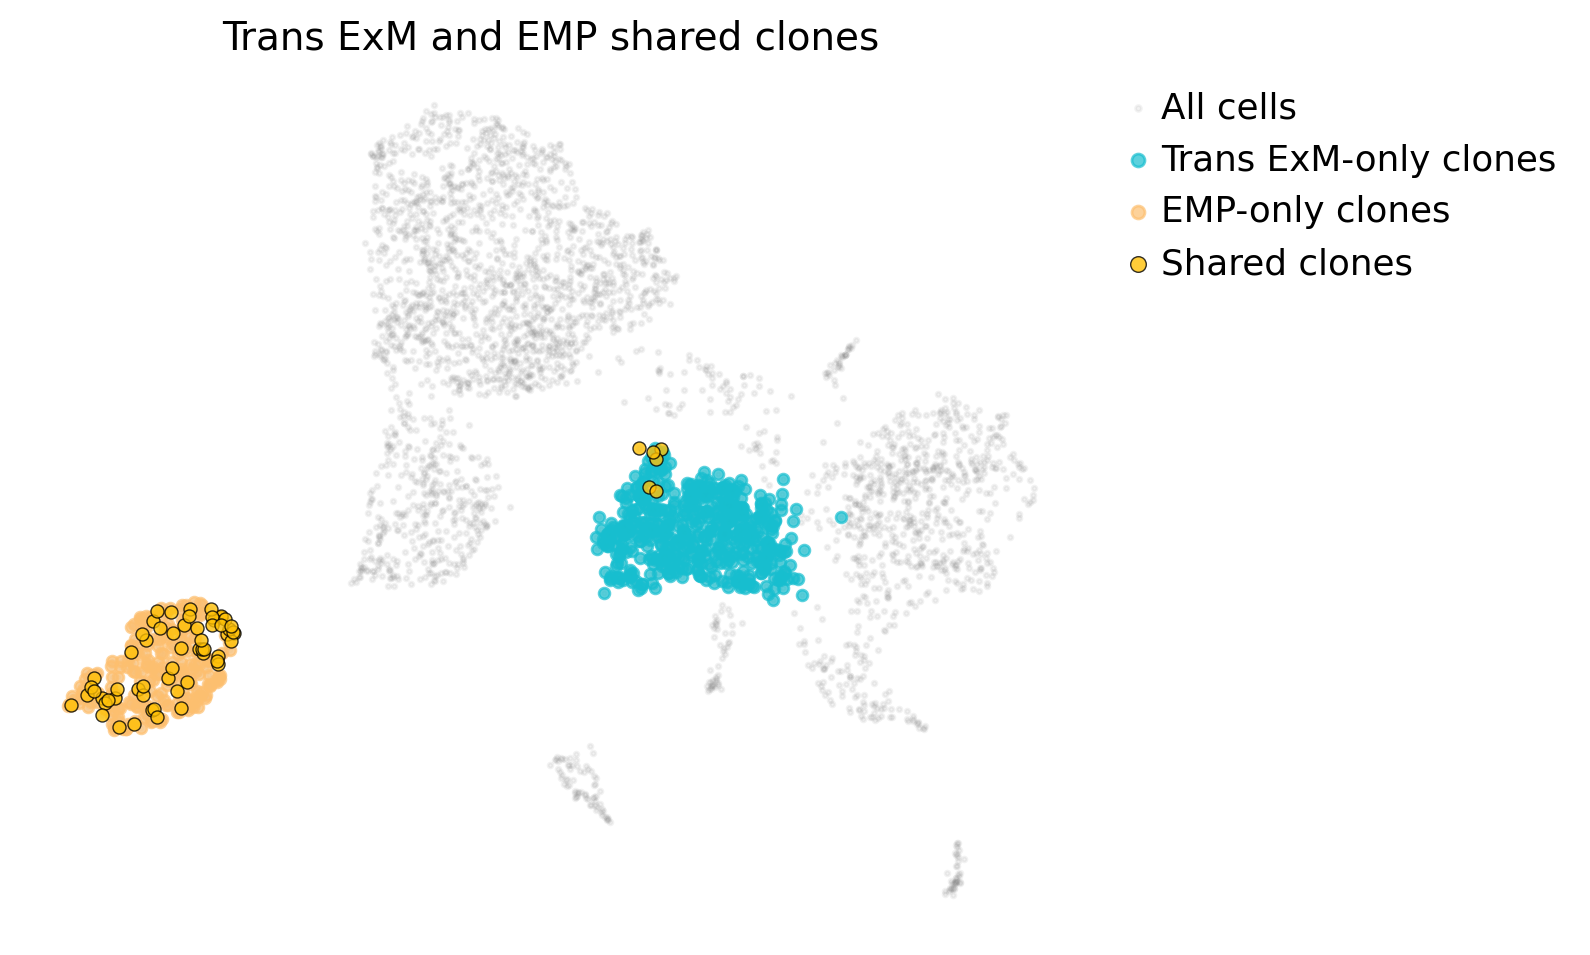

Trans ExM-only cells: 513
EMP-only cells: 225
Shared cells: 65


In [37]:
fig, ax, mixed_clone_ids = plot_AB_clone(
    adata=larry_d7,
    celltype_label="CellType_short",
    celltype_A="Trans ExM",
    celltype_B="EMP",
    colorA=celltype_palette["Trans ExM"],
    colorB=celltype_palette["EMP"],
    colorC="#FFC107",
    figsize=(8.2, 5),
    point_size_bg=3,
    point_size_celltype=15,
    point_size_shared=22,
    title="Trans ExM and EMP shared clones",
    legend_loc="upper left",
    legend_bbox_to_anchor=(1.02, 1),
    save_path= fig_dir / 'd7_trans_exm_to_emp.pdf'
)

ANALYSIS: How many clones of different sources go to Trans ExM?
Target cell type: Trans ExM (507 clones)
Metric: (shared clones between source and B) / (source clones)

RESULTS (sorted by percentage, highest first):
   Source  Source Clones  Shared Clones  Percentage (shared/source) Ratio (shared/source)
      PGC             55              3                        5.45                  3/55
 Endoderm             37              2                        5.41                  2/37
      EMP             61              3                        4.92                  3/61
       PS             70              2                        2.86                  2/70
       HE            223              6                        2.69                 6/223
  Adv Mes            517             11                        2.13                11/517
      Epi             86              1                        1.16                  1/86
      Amn            429              2                        0

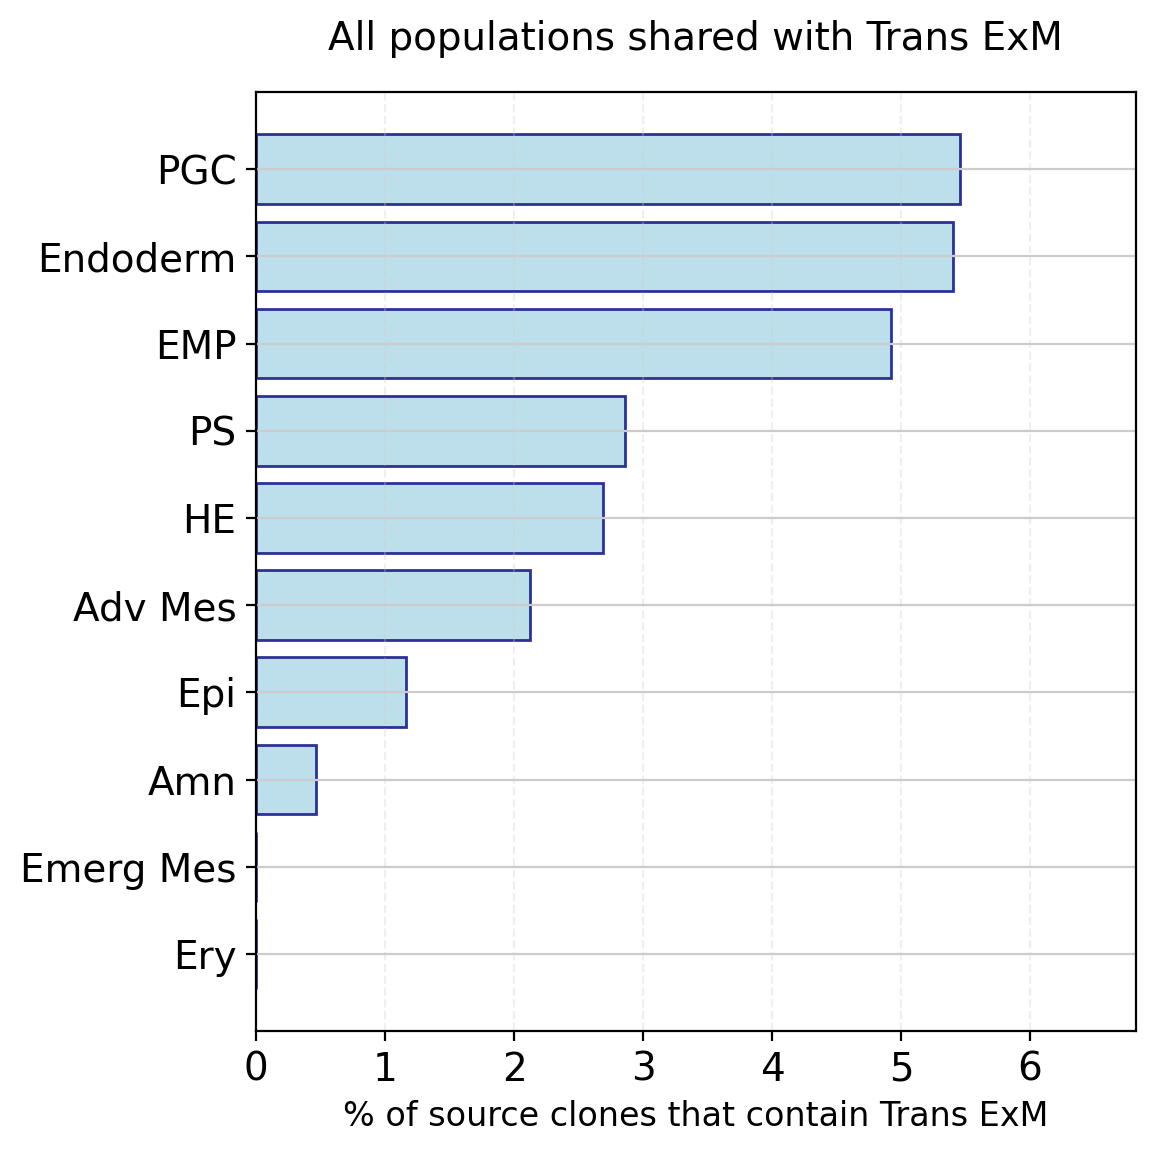

In [38]:
results_all_to_trans = visualize_all_populations_to_B(
    adata=larry_d7,
    column_to_check="CellType_short",
    target_B="Trans ExM",
    min_source_clones=3,
    fig_title="All populations shared with Trans ExM",
    figsize=(6, 6),
    save_path=fig_dir / "d7_all_populations_to_trans_exm.pdf",
)        

ANALYSIS: How many clones of different sources go to Adv Mes?
Target cell type: Adv Mes (517 clones)
Metric: (shared clones between source and B) / (source clones)

RESULTS (sorted by percentage, highest first):
   Source  Source Clones  Shared Clones  Percentage (shared/source) Ratio (shared/source)
       HE            223            140                       62.78               140/223
      EMP             61             28                       45.90                 28/61
       PS             70             29                       41.43                 29/70
      PGC             55             16                       29.09                 16/55
 Endoderm             37              9                       24.32                  9/37
      Epi             86             19                       22.09                 19/86
      Amn            429             70                       16.32                70/429
Emerg Mes             16              2                       12.50 

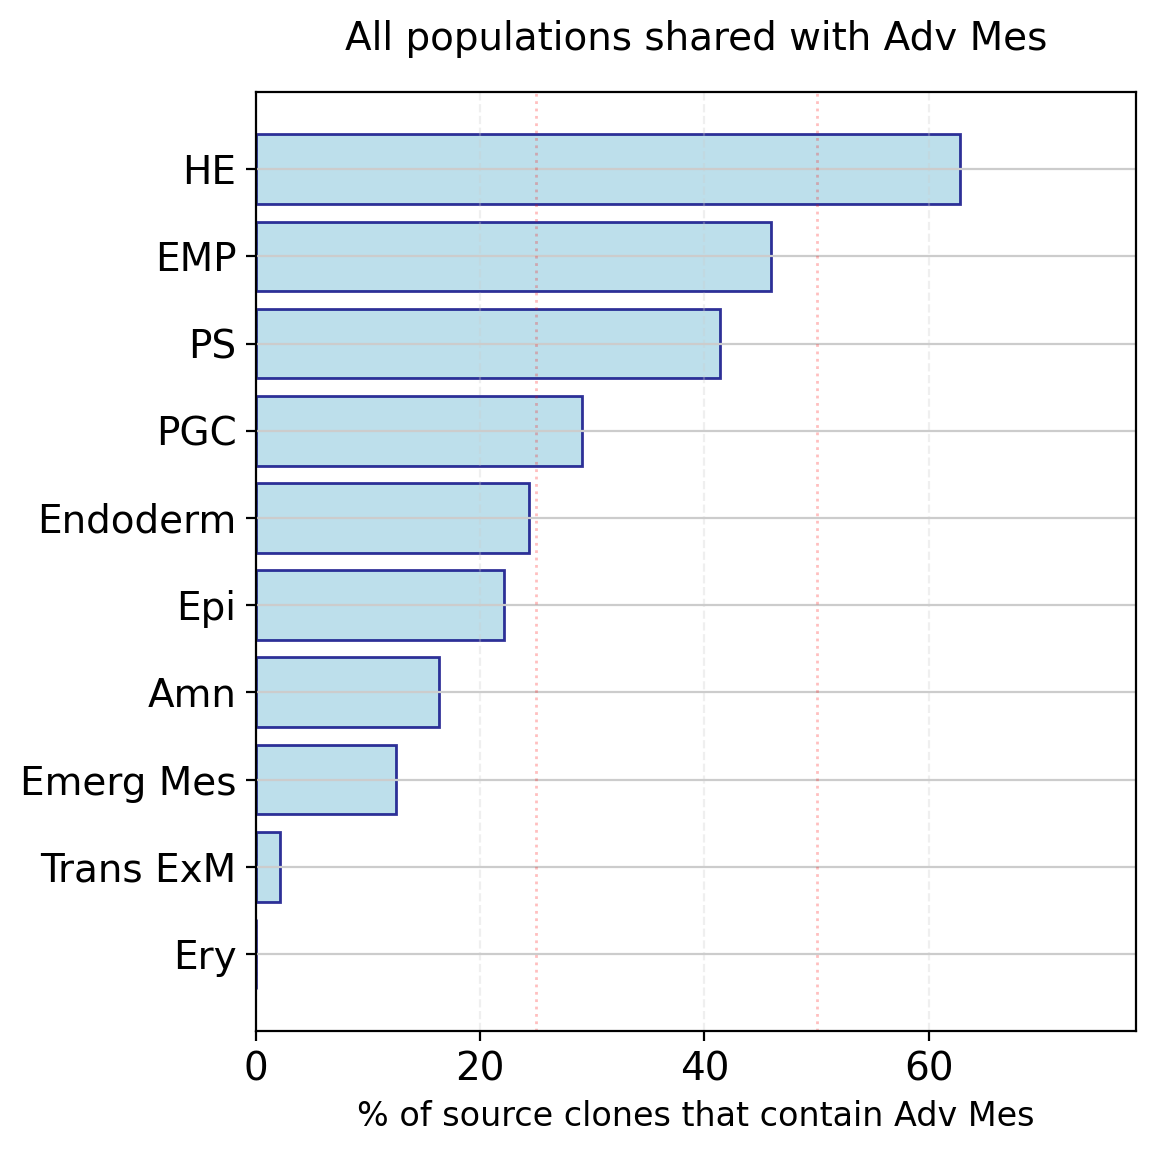

In [39]:
results_all_to_trans = visualize_all_populations_to_B(
    adata=larry_d7,
    column_to_check="CellType_short",
    target_B="Adv Mes",
    min_source_clones=3,
    fig_title="All populations shared with Adv Mes",
    figsize=(6, 6),
    save_path=fig_dir / "d7_all_populations_to_adv_mes.pdf",
)        

ANALYSIS: How many clones of different sources go to Emerg Mes?
Target cell type: Emerg Mes (16 clones)
Metric: (shared clones between source and B) / (source clones)

RESULTS (sorted by percentage, highest first):
   Source  Source Clones  Shared Clones  Percentage (shared/source) Ratio (shared/source)
 Endoderm             37              1                        2.70                  1/37
      Epi             86              2                        2.33                  2/86
       PS             70              1                        1.43                  1/70
      Amn            429              3                        0.70                 3/429
       HE            223              1                        0.45                 1/223
  Adv Mes            517              2                        0.39                 2/517
      Ery             39              0                        0.00                  0/39
      EMP             61              0                        0.

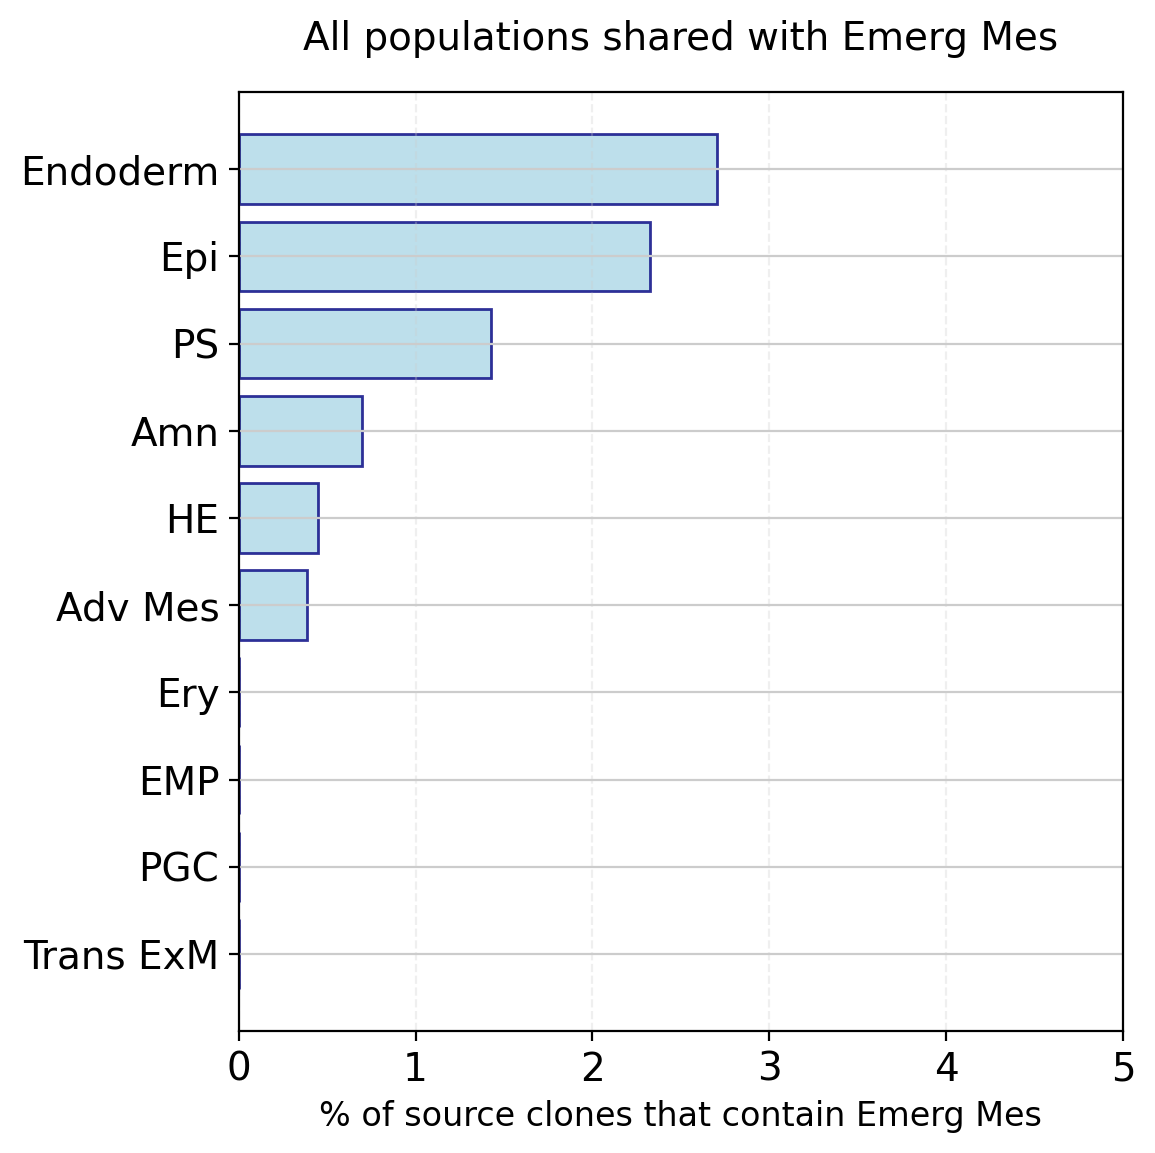

In [40]:
results_all_to_trans = visualize_all_populations_to_B(
    adata=larry_d7,
    column_to_check="CellType_short",
    target_B="Emerg Mes",
    min_source_clones=3,
    fig_title="All populations shared with Emerg Mes",
    figsize=(6, 6),
    save_path=fig_dir / "d7_all_populations_to_emerg_mes.pdf",
)        

ANALYSIS: How many clones of different sources go to HE?
Target cell type: HE (223 clones)
Metric: (shared clones between source and B) / (source clones)

RESULTS (sorted by percentage, highest first):
   Source  Source Clones  Shared Clones  Percentage (shared/source) Ratio (shared/source)
      EMP             61             23                       37.70                 23/61
  Adv Mes            517            140                       27.08               140/517
       PS             70             18                       25.71                 18/70
 Endoderm             37              6                       16.22                  6/37
      Epi             86             10                       11.63                 10/86
      PGC             55              5                        9.09                  5/55
      Amn            429             36                        8.39                36/429
Emerg Mes             16              1                        6.25           

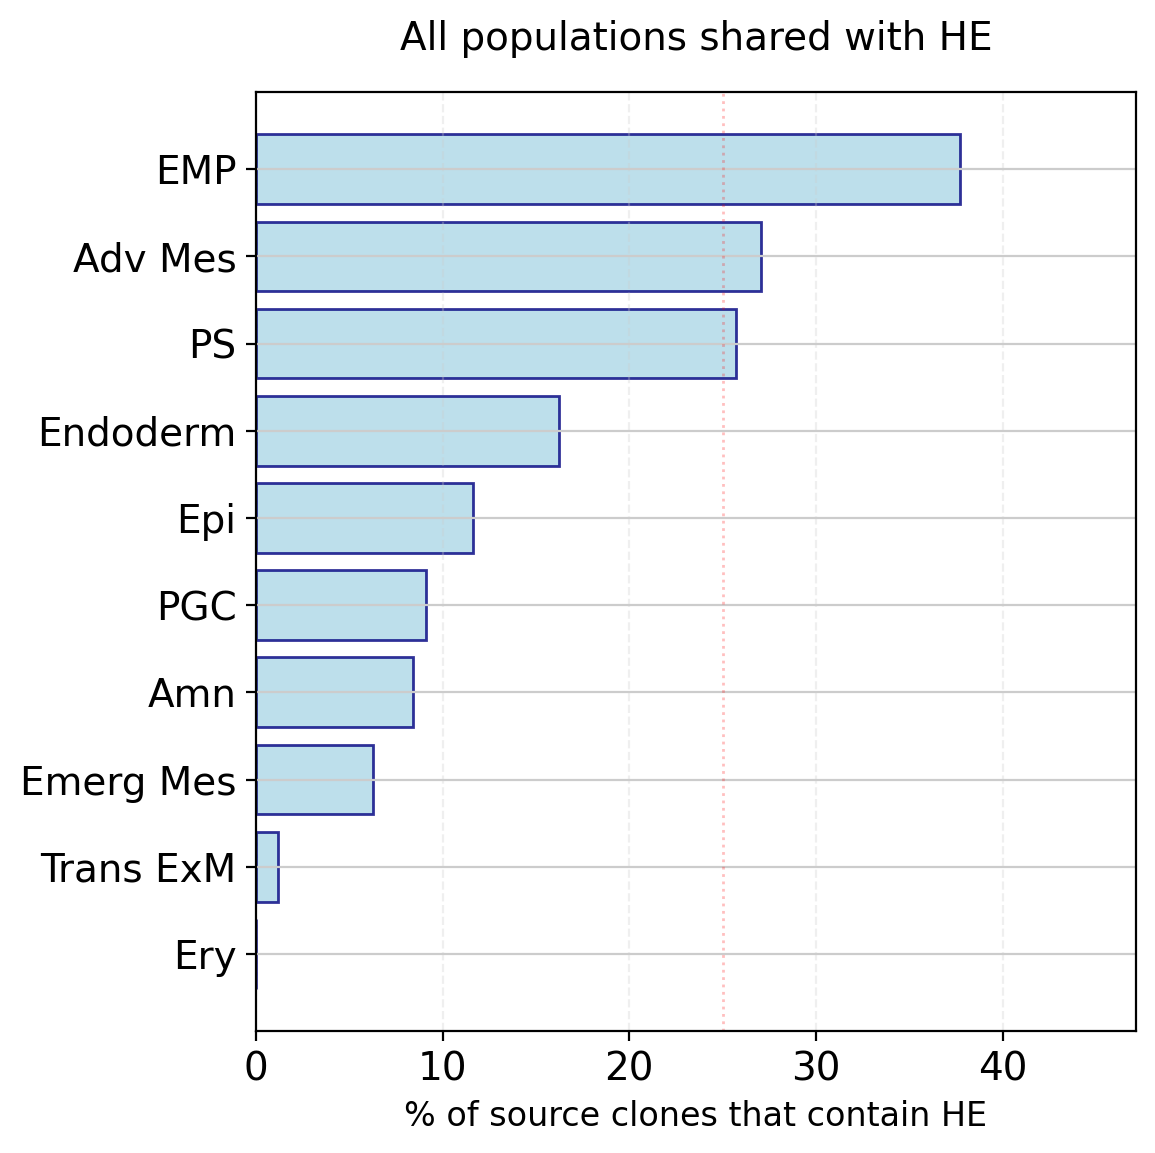

In [57]:
results_all_to_trans = visualize_all_populations_to_B(
    adata=larry_d7,
    column_to_check="CellType_short",
    target_B="HE",
    min_source_clones=3,
    fig_title="All populations shared with HE",
    figsize=(6, 6),
    save_path=fig_dir / "d7_all_populations_to_he.pdf",
)        

ANALYSIS: How many clones of different sources go to EMP?
Target cell type: EMP (61 clones)
Metric: (shared clones between source and B) / (source clones)

RESULTS (sorted by percentage, highest first):
   Source  Source Clones  Shared Clones  Percentage (shared/source) Ratio (shared/source)
       HE            223             23                       10.31                23/223
       PS             70              7                       10.00                  7/70
  Adv Mes            517             28                        5.42                28/517
 Endoderm             37              2                        5.41                  2/37
      Epi             86              2                        2.33                  2/86
      PGC             55              1                        1.82                  1/55
      Amn            429              7                        1.63                 7/429
Trans ExM            507              3                        0.59          

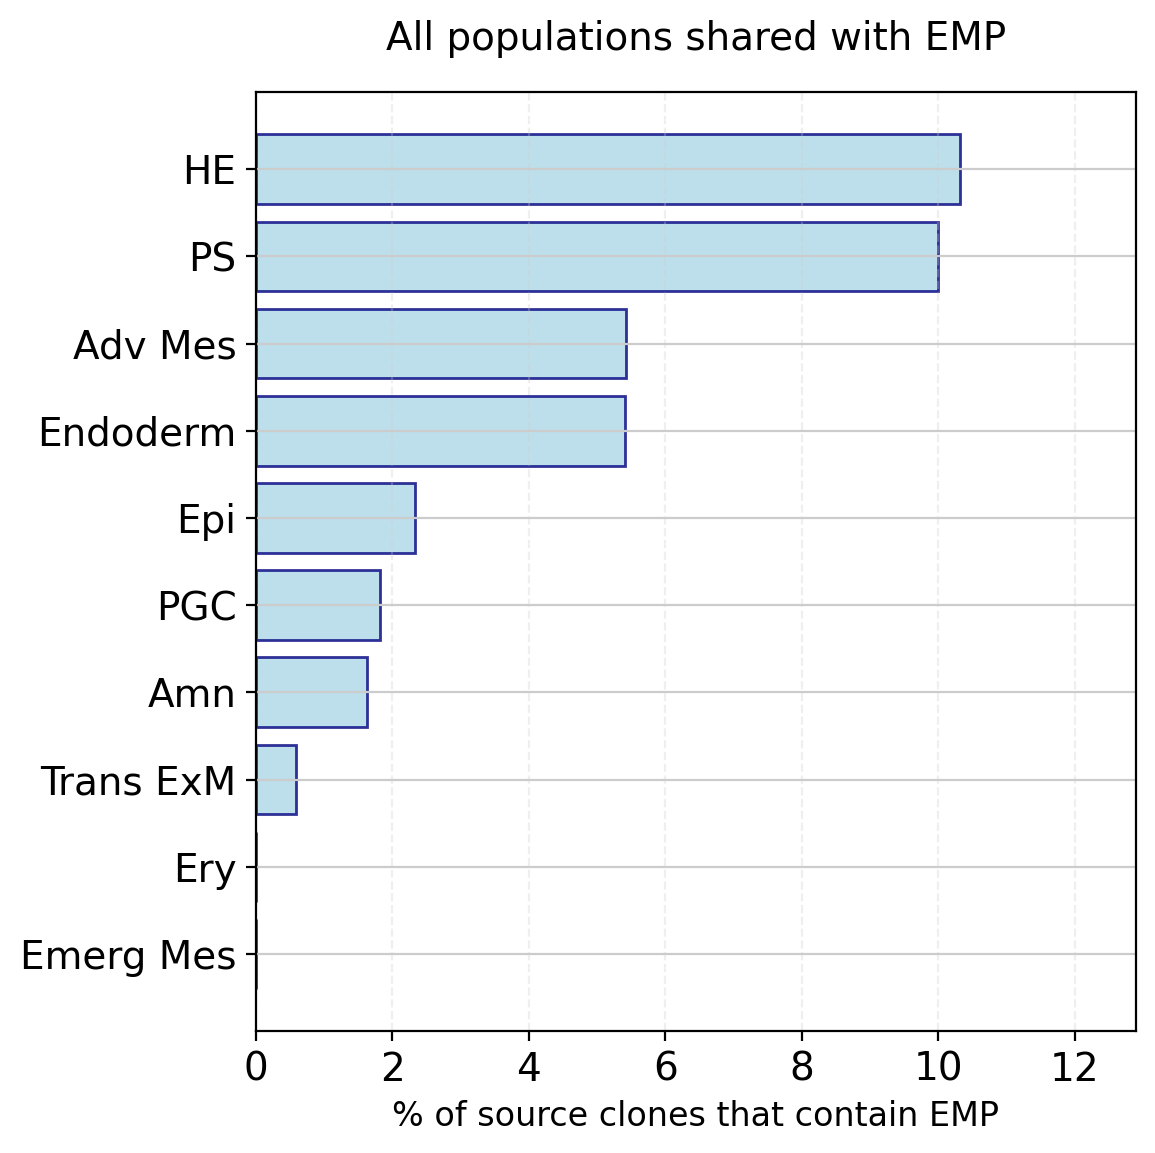

In [41]:
results_all_to_trans = visualize_all_populations_to_B(
    adata=larry_d7,
    column_to_check="CellType_short",
    target_B="EMP",
    min_source_clones=3,
    fig_title="All populations shared with EMP",
    figsize=(6, 6),
    save_path=fig_dir / "d7_all_populations_to_emp.pdf",
)        

In [42]:
candidate_paths = [
    Path("/mnt/yiming/nfs_share/projects/hypoblast/results/processed/larry_d12_revised_labels.h5ad"),
]

larry_d12_path = next((p for p in candidate_paths if p.exists()), None)
if larry_d12_path is None:
    raise FileNotFoundError(
        "Could not find the Day 12 LARRY h5ad file. Checked:\n" +
        "\n".join(str(p) for p in candidate_paths)
    )

larry_d12 = sc.read_h5ad(larry_d12_path)
print(f"Loaded: {larry_d12_path}")
print(larry_d12)

celltype_key = 'CellType_short'

Loaded: /mnt/yiming/nfs_share/projects/hypoblast/results/processed/larry_d12_revised_labels.h5ad
AnnData object with n_obs × n_vars = 9010 × 29669
    obs: 'scrublet_result', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'larry_barcode', 'larry_clone', 'CellType_man', 'CellType_revised_short', 'CellType_revised', 'CellType_revised_full', 'CellType_short'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'CellType_man_colors', 'CellType_short_colors', 'Ng_label_colors', 'Tyser_label_colors', 'Tyser_label_v2_colors', 'annotation_combine_colors',

In [43]:
clone_key = "larry_clone"
required_obs = [celltype_key, clone_key]
missing_obs = [x for x in required_obs if x not in larry_d12.obs.columns]
if missing_obs:
    raise KeyError(f"Missing required obs columns: {missing_obs}")

qc_summary = pd.Series({
    "n_cells": larry_d12.n_obs,
    "n_genes": larry_d12.n_vars,
    "n_annotated_cells": larry_d12.obs[celltype_key].notna().sum(),
    "n_clone_assigned_cells": larry_d12.obs[clone_key].notna().sum(),
    "n_unique_clones": larry_d12.obs[clone_key].dropna().astype(str).nunique(),
}, name="value").to_frame()
qc_summary.to_csv(table_dir / "larry_d12_basic_qc.csv")
qc_summary

,value
n_cells,9010
n_genes,29669
n_annotated_cells,9010
n_clone_assigned_cells,9010
n_unique_clones,1838


In [44]:
clone_sizes = (
    larry_d12.obs.loc[larry_d12.obs[clone_key].notna(), clone_key]
    .astype(str)
    .value_counts()
    .rename_axis("clone_id")
    .rename("n_cells")
    .to_frame()
)
clone_sizes.to_csv(table_dir / "larry_d12_clone_sizes.csv")
clone_sizes.describe()

,n_cells
count,1838.000000
mean,4.902067
std,19.623655
min,1.000000
25%,1.000000
50%,1.000000
75%,3.000000
max,426.000000


In [45]:
clonality_report_dir = fig_dir / 'd12_full_clonality_report'

clonality_results = generate_full_clone_report(
    larry_d12,
    output_dir=str(clonality_report_dir),
    dataset_name='larry_d12',
    return_data=True,
)

# Save the clone-sharing Jaccard matrix as a table.
larry_d12_jaccard_df = pd.DataFrame(
    clonality_results['jaccard_matrix'],
    index=clonality_results['cell_types'],
    columns=clonality_results['cell_types'],
)
larry_d12_jaccard_df.to_csv(table_dir / 'larry_d12_celltype_clone_jaccard_matrix.csv')
larry_d12_jaccard_df

Clonality Report: larry_d12
--------------------------------------------------
Total clones: 1838
Gini coefficient: 0.6936
Shannon entropy: 8.8469
Normalized entropy: 0.8158
Simpson diversity: 0.9907
Expansion index: 0.8896


,Adv Mes,Amn,Art,EMP,Ery,Gran,Mk,PGC,Vein,YS Mes
Adv Mes,1.000000,0.112626,0.039779,0.029474,0.059928,0.005537,0.037791,0.019502,0.076591,0.142281
Amn,0.112626,1.000000,0.008547,0.019152,0.029189,0.000000,0.018226,0.011429,0.029610,0.039306
Art,0.039779,0.008547,1.000000,0.038462,0.030120,0.048387,0.031674,0.010309,0.068966,0.098859
EMP,0.029474,0.019152,0.038462,1.000000,0.203175,0.133333,0.274038,0.022727,0.037838,0.065359
Ery,0.059928,0.029189,0.030120,0.203175,1.000000,0.040404,0.245383,0.020896,0.039062,0.094456
Gran,0.005537,0.000000,0.048387,0.133333,0.040404,1.000000,0.059783,0.015625,0.008264,0.015873
Mk,0.037791,0.018226,0.031674,0.274038,0.245383,0.059783,1.000000,0.008850,0.021505,0.066158
PGC,0.019502,0.011429,0.010309,0.022727,0.020896,0.015625,0.008850,1.000000,0.019737,0.035842
Vein,0.076591,0.029610,0.068966,0.037838,0.039062,0.008264,0.021505,0.019737,1.000000,0.094937
YS Mes,0.142281,0.039306,0.098859,0.065359,0.094456,0.015873,0.066158,0.035842,0.094937,1.000000


ANALYSIS: How many clones of different sources go to Ery?
Target cell type: Ery (293 clones)
Metric: (shared clones between source and B) / (source clones)

RESULTS (sorted by percentage, highest first):
Source  Source Clones  Shared Clones  Percentage (shared/source) Ratio (shared/source)
   EMP             86             64                       74.42                 64/86
YS Mes            240             46                       19.17                46/240
Figure saved to results/figures/312_larry_clonality/d12_hceb_lineage_to_ery.pdf


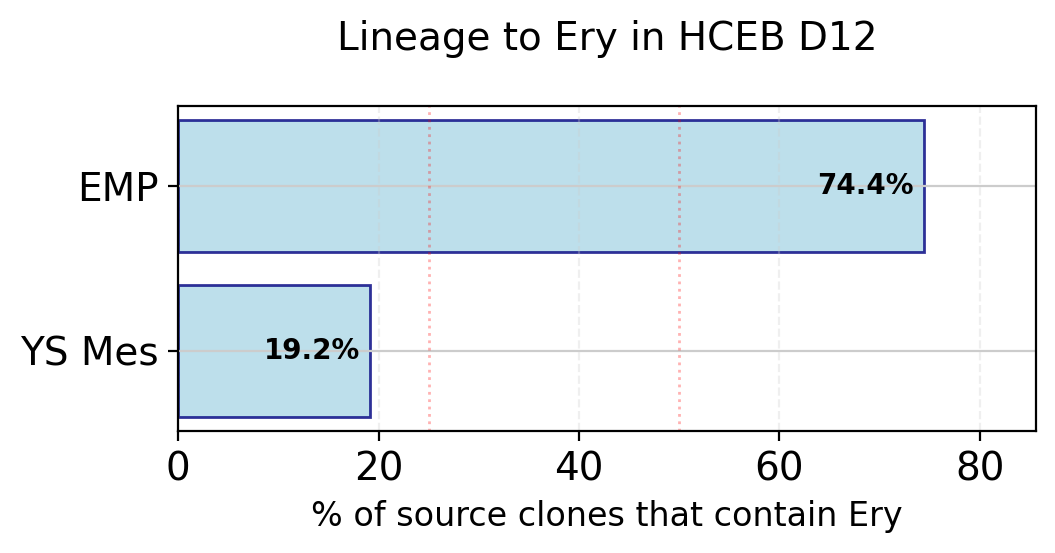

,Source,Target,Source Clones,Target Clones,Shared Clones,Clones with Both,Percentage (shared/source),Ratio (shared/source),Shared Clone IDs,Clones with Both IDs
0,EMP,Ery,86,293,64,64,74.418605,64/86,"[clone_97, clone_366, clone_11, clone_166, clo...","[clone_97, clone_366, clone_11, clone_166, clo..."
1,YS Mes,Ery,240,293,46,46,19.166667,46/240,"[clone_5, clone_97, clone_366, clone_329, clon...","[clone_5, clone_97, clone_366, clone_329, clon..."


In [46]:
# Helper functions are defined in the embedded 05_lineage.py section above.
visualize_sources_to_B(
    larry_d12,
    'CellType_short',
    ['EMP', 'YS Mes'],
    'Ery',
    figsize=(5.5, 3),
    fig_title='Lineage to Ery in HCEB D12',
    save_path=fig_dir / 'd12_hceb_lineage_to_ery.pdf'
)

Population figure saved to results/figures/312_larry_clonality/d12_emp_and_ery.pdf


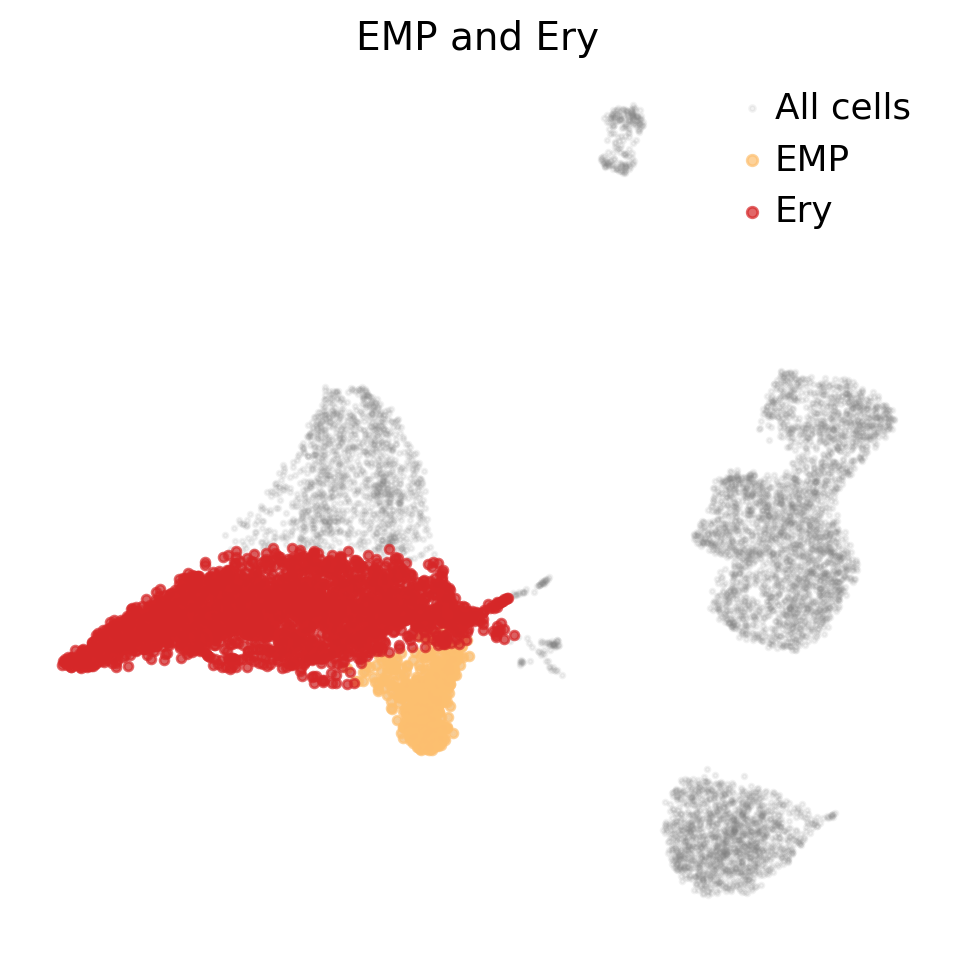

(<Figure size 500x500 with 1 Axes>, <Axes: title={'center': 'EMP and Ery'}>)

In [47]:
plot_AB_population(
    adata=larry_d12,
    celltype_label="CellType_short",
    celltype_A="EMP",
    celltype_B="Ery",
    colorA=celltype_palette["EMP"],
    colorB=celltype_palette["Ery"],
    figsize=(5, 5),
    point_size_bg=3,
    point_size_celltype=10,
    title="EMP and Ery",
    save_path= fig_dir / 'd12_emp_and_ery.pdf'
)

Recovering AB clone type from larry_clone...


Mixed clones containing both EMP and Ery: 64
EMP-only cells: 23
Ery-only cells: 546
Shared cells: 2550
Clone sharing figure saved to results/figures/312_larry_clonality/d12_emp_to_ery.pdf


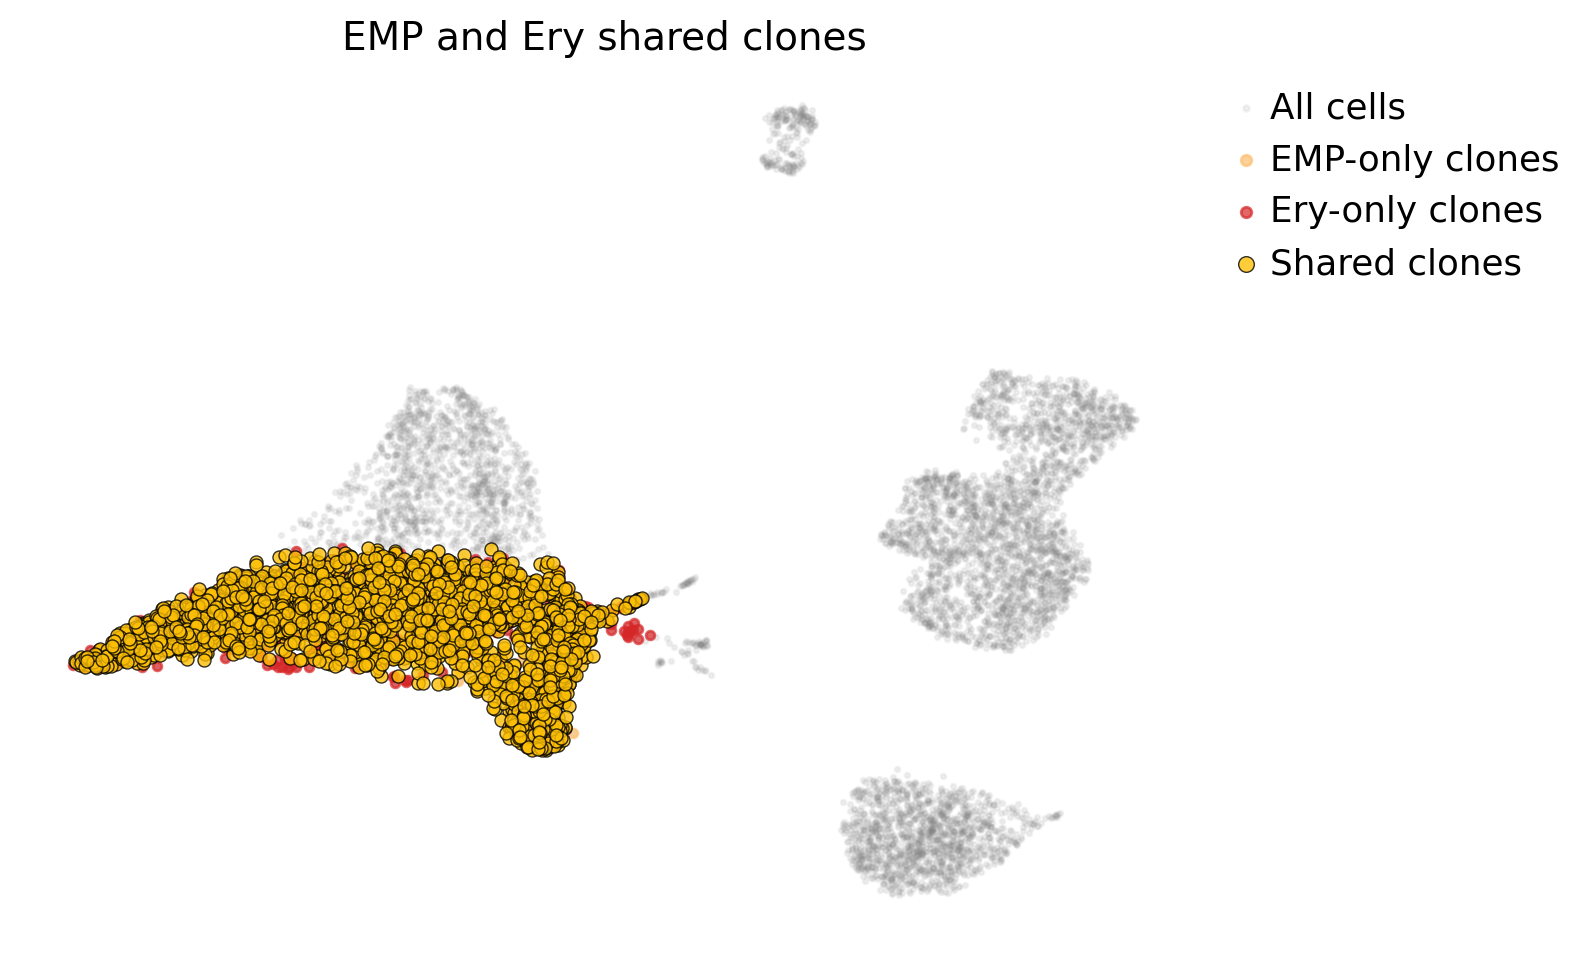

EMP-only cells: 23
Ery-only cells: 546
Shared cells: 2550


In [48]:
fig, ax, mixed_clone_ids = plot_AB_clone(
    adata=larry_d12,
    celltype_label="CellType_short",
    celltype_A="EMP",
    celltype_B="Ery",
    colorA=celltype_palette["EMP"],
    colorB=celltype_palette["Ery"],
    colorC="#FFC107",
    figsize=(8.2, 5),
    point_size_bg=3,
    point_size_celltype=10,
    point_size_shared=22,
    title="EMP and Ery shared clones",
    legend_loc="upper left",
    legend_bbox_to_anchor=(1.02, 1),
    save_path= fig_dir / 'd12_emp_to_ery.pdf'
)

Population figure saved to results/figures/312_larry_clonality/d12_ys_mes_and_ery.pdf


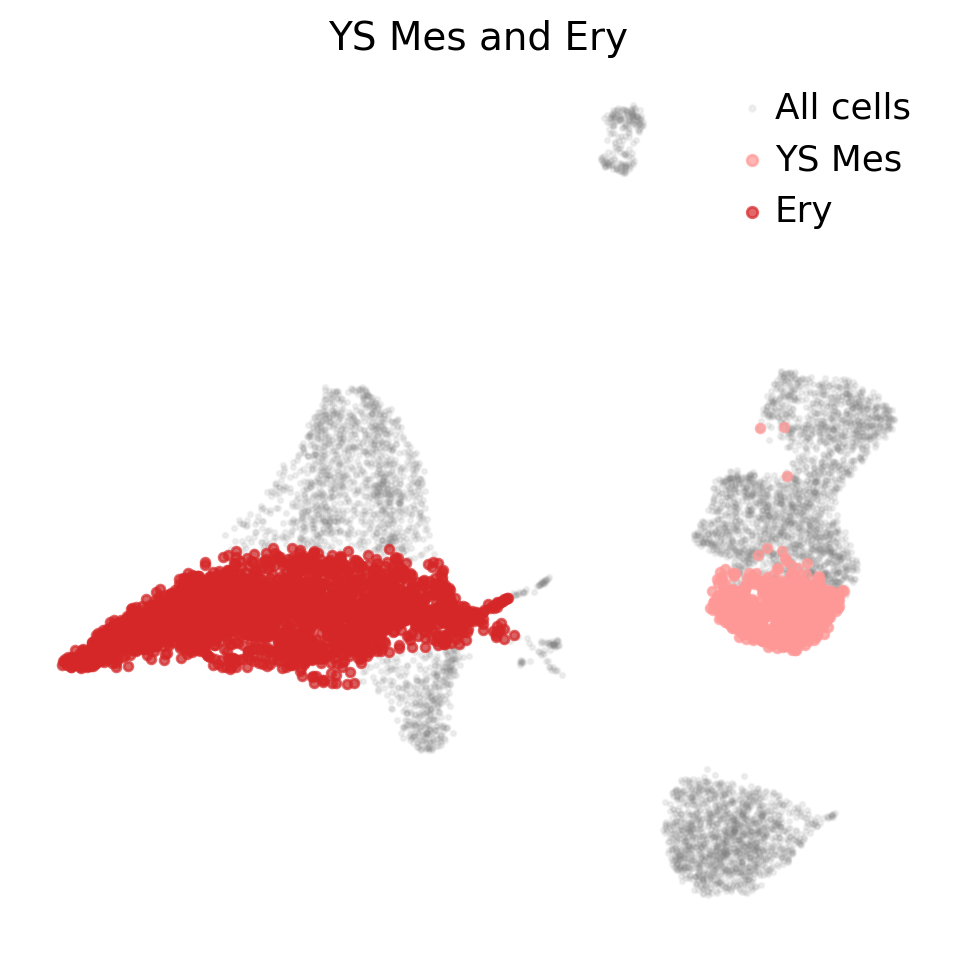

(<Figure size 500x500 with 1 Axes>, <Axes: title={'center': 'YS Mes and Ery'}>)

In [49]:
plot_AB_population(
    adata=larry_d12,
    celltype_label="CellType_short",
    celltype_A="YS Mes",
    celltype_B="Ery",
    colorA=celltype_palette["YS Mes"],
    colorB=celltype_palette["Ery"],
    figsize=(5, 5),
    point_size_bg=3,
    point_size_celltype=10,
    title="YS Mes and Ery",
    save_path= fig_dir / 'd12_ys_mes_and_ery.pdf'
)

Recovering AB clone type from larry_clone...


Mixed clones containing both YS Mes and Ery: 46
YS Mes-only cells: 443
Ery-only cells: 2014
Shared cells: 846
Clone sharing figure saved to results/figures/312_larry_clonality/d12_ys_mes_to_ery.pdf


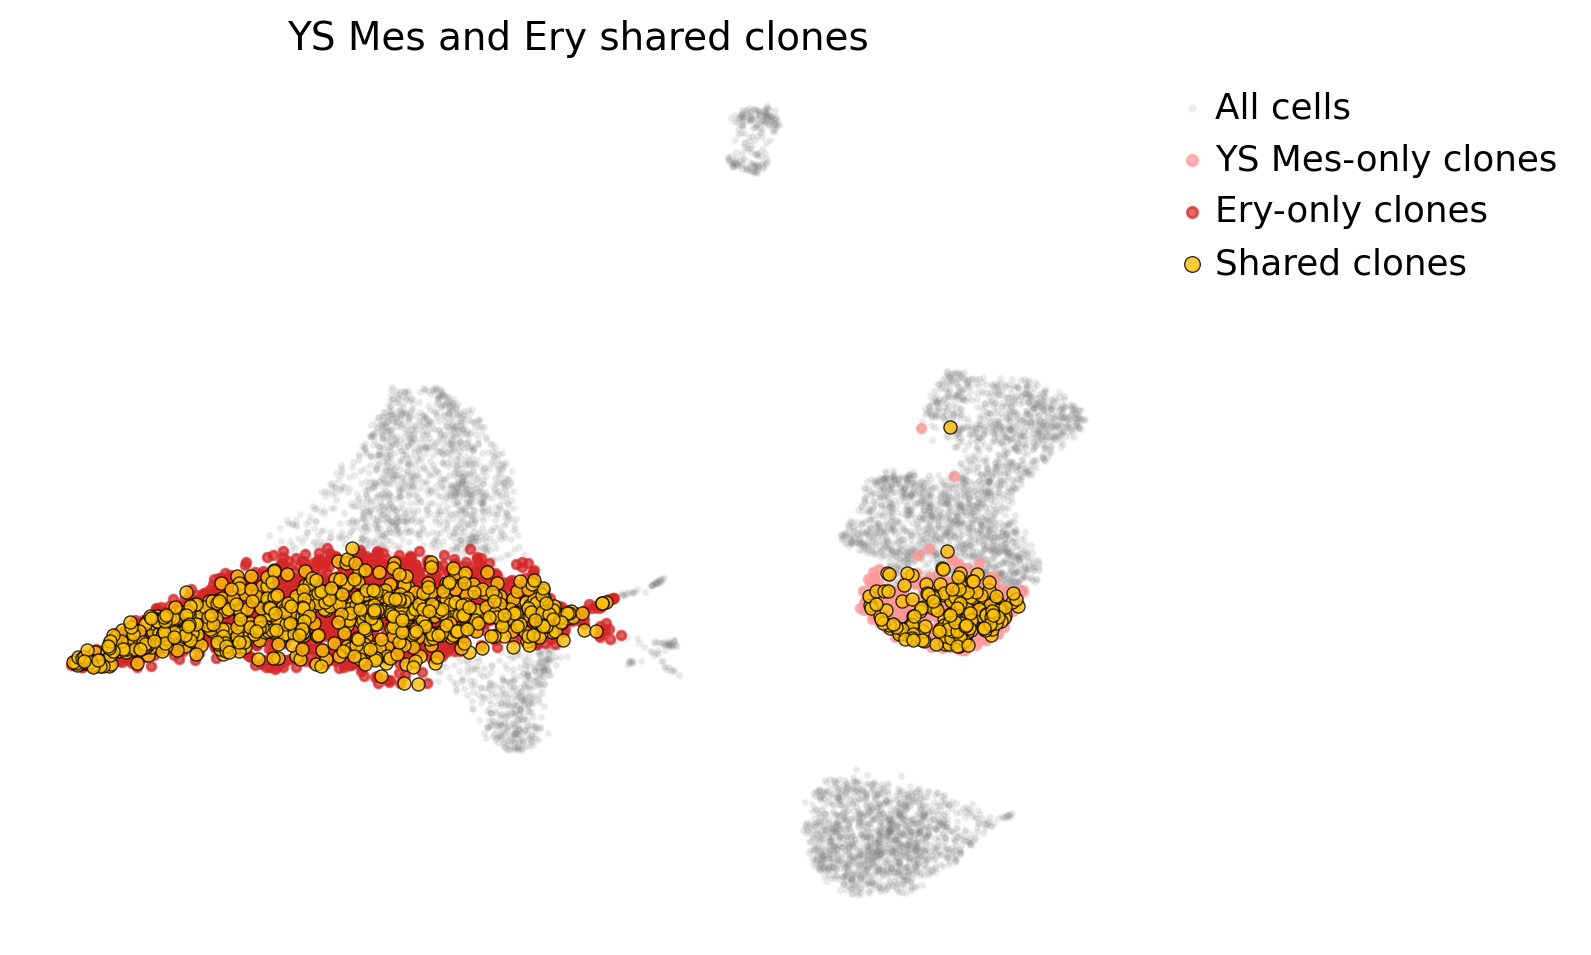

YS Mes-only cells: 443
Ery-only cells: 2014
Shared cells: 846


In [50]:
fig, ax, mixed_clone_ids = plot_AB_clone(
    adata=larry_d12,
    celltype_label="CellType_short",
    celltype_A="YS Mes",
    celltype_B="Ery",
    colorA=celltype_palette["YS Mes"],
    colorB=celltype_palette["Ery"],
    colorC="#FFC107",
    figsize=(8.2, 5),
    point_size_bg=3,
    point_size_celltype=10,
    point_size_shared=22,
    title="YS Mes and Ery shared clones",
    legend_loc="upper left",
    legend_bbox_to_anchor=(1.02, 1),
    save_path= fig_dir / 'd12_ys_mes_to_ery.pdf'
)

Recovering AB clone type from larry_clone...
Mixed clones containing both Adv Mes and Vein: 71
Adv Mes-only cells: 1975
Vein-only cells: 36
Shared cells: 418
Clone sharing figure saved to results/figures/312_larry_clonality/d12_adv_mes_to_vein.pdf


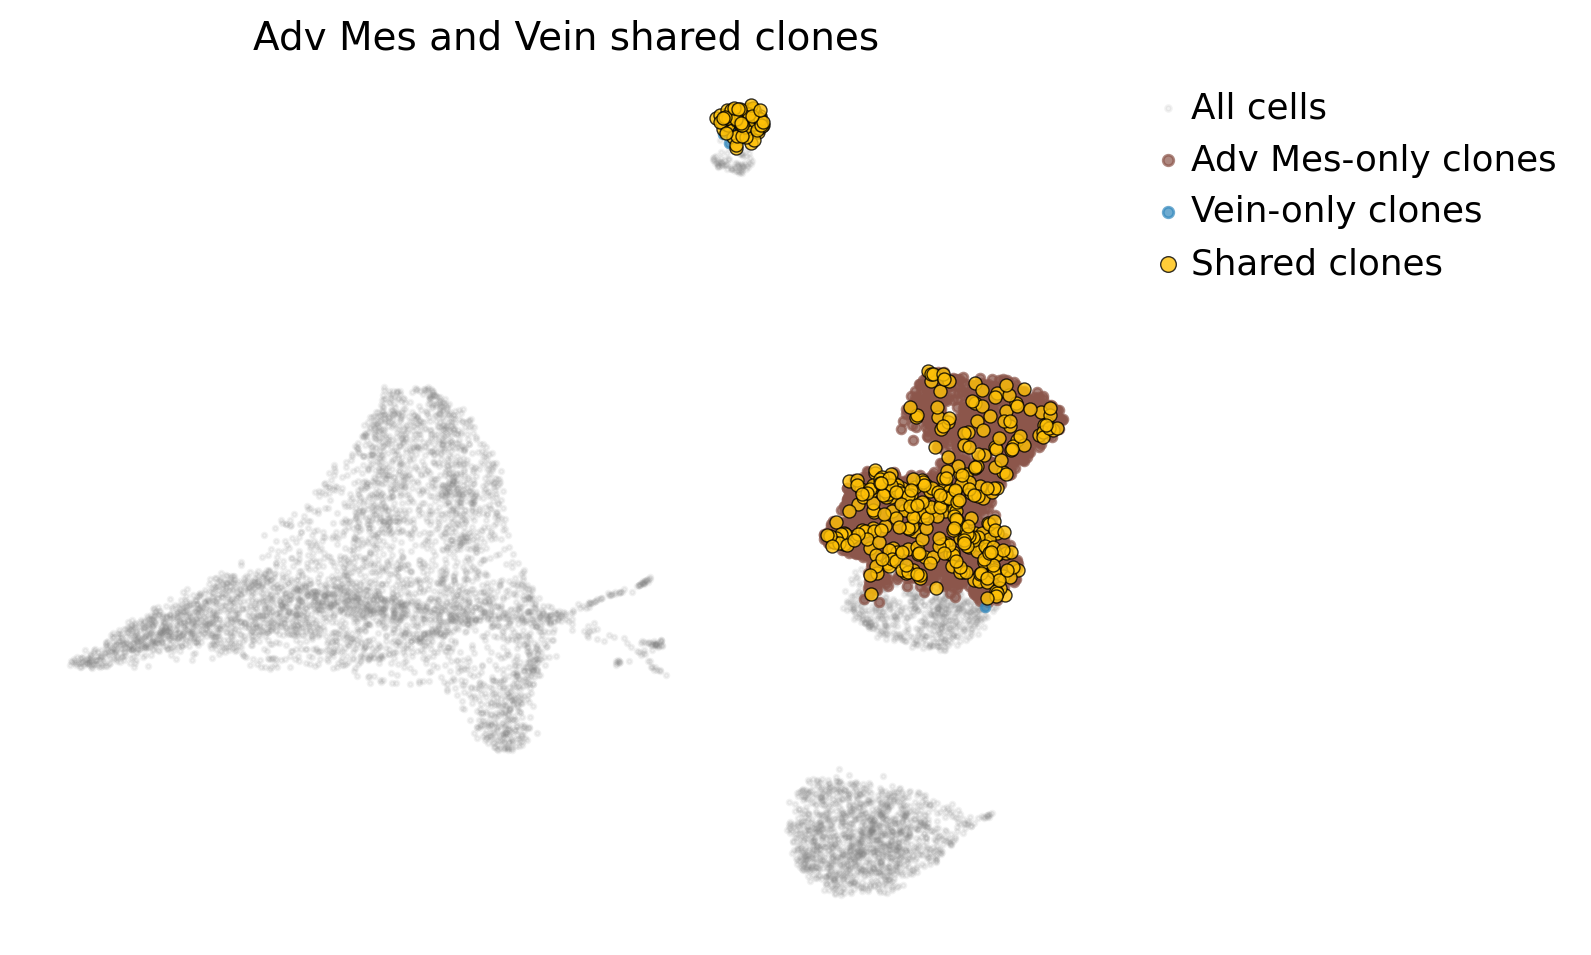

Adv Mes-only cells: 1975
Vein-only cells: 36
Shared cells: 418


In [58]:
fig, ax, mixed_clone_ids = plot_AB_clone(
    adata=larry_d12,
    celltype_label="CellType_short",
    celltype_A="Adv Mes",
    celltype_B="Vein",
    colorA=celltype_palette["Adv Mes"],
    colorB=celltype_palette["Vein"],
    colorC="#FFC107",
    figsize=(8.2, 5),
    point_size_bg=3,
    point_size_celltype=10,
    point_size_shared=22,
    title="Adv Mes and Vein shared clones",
    legend_loc="upper left",
    legend_bbox_to_anchor=(1.02, 1),
    save_path= fig_dir / 'd12_adv_mes_to_vein.pdf'
)

ANALYSIS: How many clones of different sources go to Ery?
Target cell type: Ery (293 clones)
Metric: (shared clones between source and B) / (source clones)

RESULTS (sorted by percentage, highest first):
 Source  Source Clones  Shared Clones  Percentage (shared/source) Ratio (shared/source)
   Gran             16             12                       75.00                 12/16
    EMP             86             64                       74.42                 64/86
     Mk            179             93                       51.96                93/179
    Art             49             10                       20.41                 10/49
 YS Mes            240             46                       19.17                46/240
    PGC             49              7                       14.29                  7/49
   Vein            106             15                       14.15                15/106
Adv Mes            892             67                        7.51                67/892
    

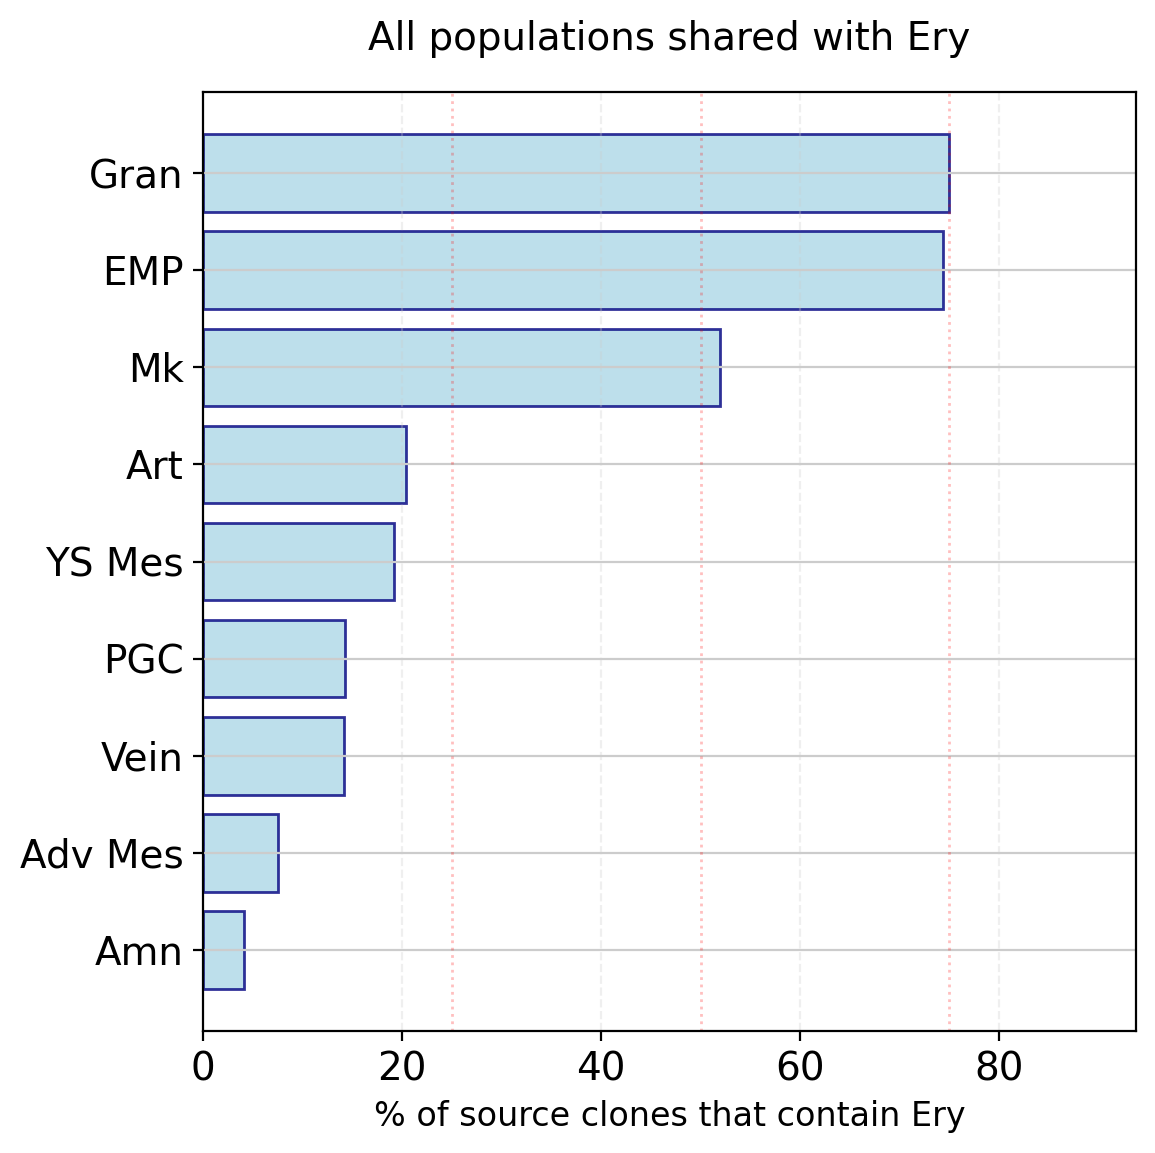

In [51]:
results_all_to_trans = visualize_all_populations_to_B(
    adata=larry_d12,
    column_to_check="CellType_short",
    target_B="Ery",
    min_source_clones=3,
    fig_title="All populations shared with Ery",
    figsize=(6, 6),
    save_path=fig_dir / "d12_all_populations_to_ery.pdf",
)        

ANALYSIS: How many clones of different sources go to EMP?
Target cell type: EMP (86 clones)
Metric: (shared clones between source and B) / (source clones)

RESULTS (sorted by percentage, highest first):
 Source  Source Clones  Shared Clones  Percentage (shared/source) Ratio (shared/source)
   Gran             16             12                       75.00                 12/16
     Mk            179             57                       31.84                57/179
    Ery            293             64                       21.84                64/293
    Art             49              5                       10.20                  5/49
 YS Mes            240             20                        8.33                20/240
   Vein            106              7                        6.60                 7/106
    PGC             49              3                        6.12                  3/49
Adv Mes            892             28                        3.14                28/892
    A

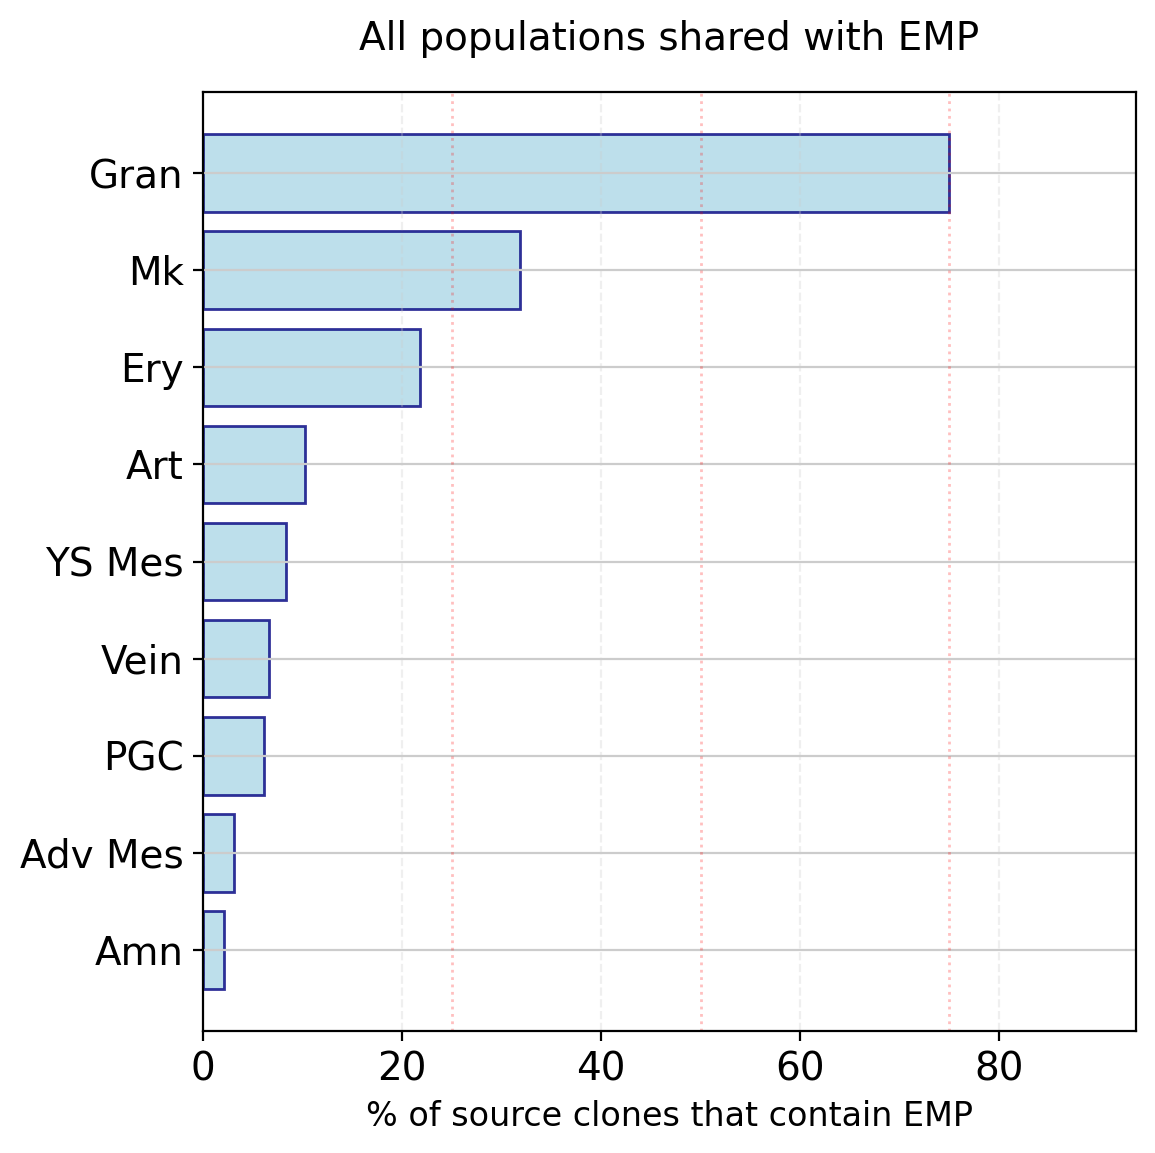

In [52]:
results_all_to_trans = visualize_all_populations_to_B(
    adata=larry_d12,
    column_to_check="CellType_short",
    target_B="EMP",
    min_source_clones=3,
    fig_title="All populations shared with EMP",
    figsize=(6, 6),
    save_path=fig_dir / "d12_all_populations_to_emp.pdf",
)        

ANALYSIS: How many clones of different sources go to YS Mes?
Target cell type: YS Mes (240 clones)
Metric: (shared clones between source and B) / (source clones)

RESULTS (sorted by percentage, highest first):
 Source  Source Clones  Shared Clones  Percentage (shared/source) Ratio (shared/source)
    Art             49             26                       53.06                 26/49
   Vein            106             30                       28.30                30/106
   Gran             16              4                       25.00                  4/16
    EMP             86             20                       23.26                 20/86
    PGC             49             10                       20.41                 10/49
Adv Mes            892            141                       15.81               141/892
    Ery            293             46                       15.70                46/293
     Mk            179             26                       14.53                26/17

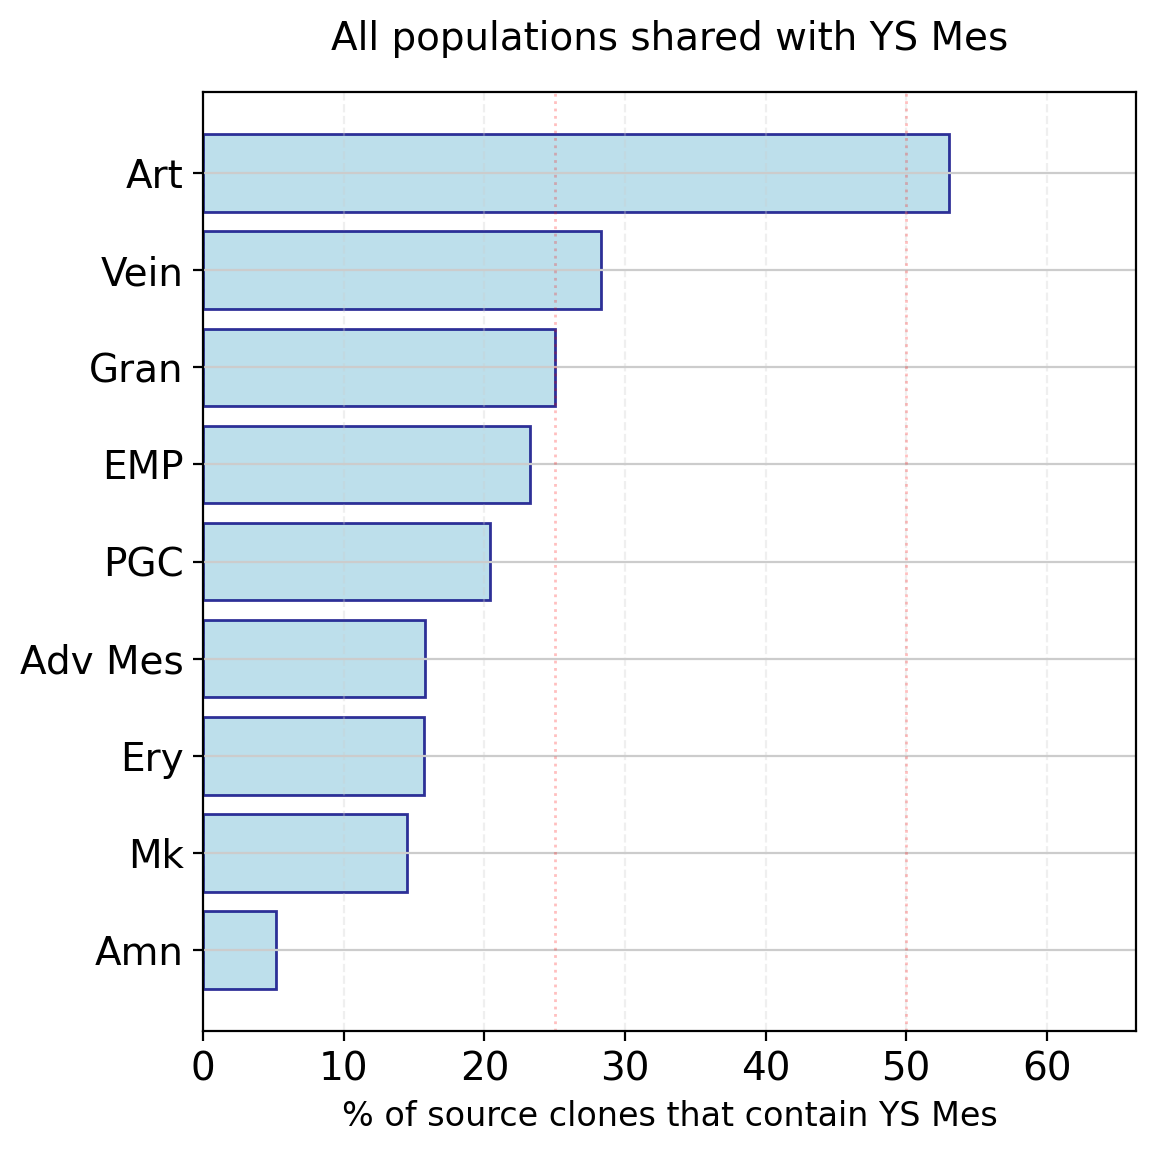

In [53]:
results_all_to_trans = visualize_all_populations_to_B(
    adata=larry_d12,
    column_to_check="CellType_short",
    target_B="YS Mes",
    min_source_clones=3,
    fig_title="All populations shared with YS Mes",
    figsize=(6, 6),
    save_path=fig_dir / "d12_all_populations_to_ys_mes.pdf",
)        

ANALYSIS: How many clones of different sources go to Adv Mes?
Target cell type: Adv Mes (892 clones)
Metric: (shared clones between source and B) / (source clones)

RESULTS (sorted by percentage, highest first):
Source  Source Clones  Shared Clones  Percentage (shared/source) Ratio (shared/source)
   Art             49             36                       73.47                 36/49
  Vein            106             71                       66.98                71/106
YS Mes            240            141                       58.75               141/240
   PGC             49             18                       36.73                 18/49
   EMP             86             28                       32.56                 28/86
  Gran             16              5                       31.25                  5/16
   Amn            659            157                       23.82               157/659
   Ery            293             67                       22.87                67/293
    M

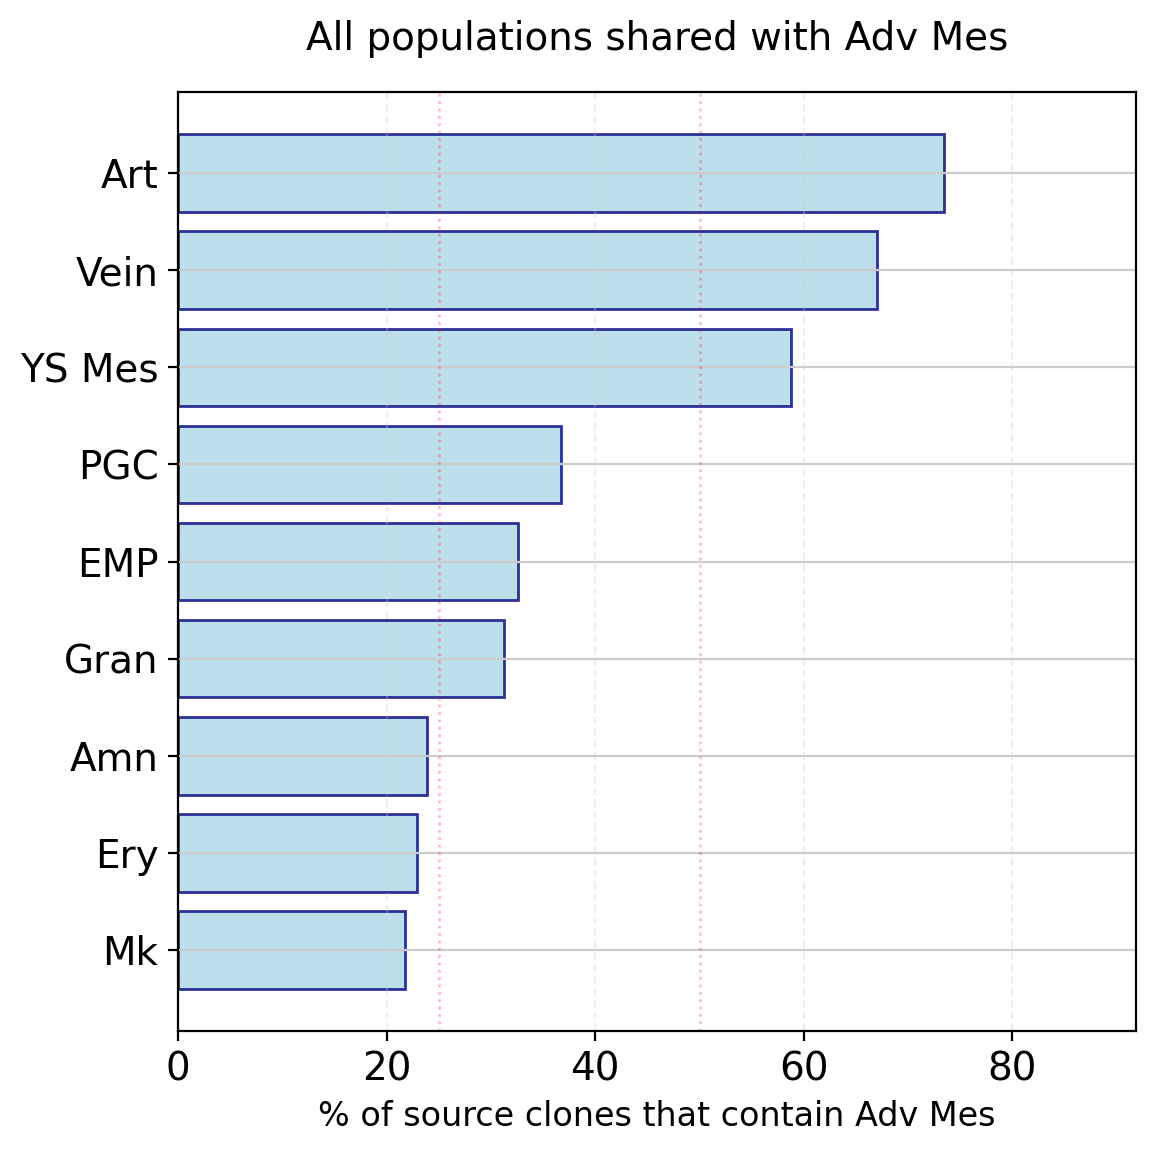

In [54]:
results_all_to_trans = visualize_all_populations_to_B(
    adata=larry_d12,
    column_to_check="CellType_short",
    target_B="Adv Mes",
    min_source_clones=3,
    fig_title="All populations shared with Adv Mes",
    figsize=(6, 6),
    save_path=fig_dir / "d12_all_populations_to_adv_mes.pdf",
)        